In [3]:
import os
import ast
import wfdb
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, f1_score  # ADDED f1_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import warnings
warnings.filterwarnings('ignore')

In [4]:
#  CONFIGURATION
 
class Config:
    # Paths
    DATASET_PATH = Path("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3")
 
    # Training
    BATCH_SIZE          = 32
    EPOCHS              = 5
    LR_MAX              = 1e-3
    LR_MIN              = 1e-6
    WARMUP_EPOCHS       = 5
    WEIGHT_DECAY        = 1e-4
 
    # Model
    CNN_CHANNELS        = [64, 128, 256, 512]
    TRANSFORMER_LAYERS  = 6
    NUM_HEADS           = 8
    DROPOUT             = 0.2
 
    # Augmentation
    USE_MIXUP           = True
    MIXUP_ALPHA         = 0.2
    AUG_PROB            = 0.7
 
    # Advanced
    LABEL_SMOOTHING     = 0.1
    GRADIENT_ACCUM_STEPS = 2
 
 
# Set seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
 
print("HYBRID CNN-TRANSFORMER — ECG CLASSIFICATION")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

HYBRID CNN-TRANSFORMER — ECG CLASSIFICATION
PyTorch : 2.8.0+cu128
CUDA    : True


In [10]:
import wandb

wandb.init(
    project="Hybrid-CNN-Transformer-ECG-notebooks_individual_notebooks",
    name="Hybrid-CNN-Transformer"
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: sdhakal13 (sdhakal13-youngstown-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [5]:
# DATA LOADING 
df = pd.read_csv(Config.DATASET_PATH / 'ptbxl_database.csv', index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(ast.literal_eval)
 
agg_df = pd.read_csv(Config.DATASET_PATH / 'scp_statements.csv', index_col=0)
 
target_labels = ['NORM', 'AFIB', 'PVC', 'LVH', 'IMI', 'ASMI', 'LAFB', 'IRBBB']
 
def get_labels(scp_codes):
    labels = np.zeros(len(target_labels), dtype=np.float32)
    for code, confidence in scp_codes.items():
        if code in target_labels and confidence >= 50:
            labels[target_labels.index(code)] = 1.0
    return labels
 
df['labels'] = df.scp_codes.apply(get_labels)
df = df[df['labels'].apply(lambda x: x.sum() > 0)].reset_index(drop=True)
 
y_all     = np.stack(df['labels'].values)
X_indices = df.index.values
 
# Train / Val / Test — 70 / 10 / 20
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(msss.split(X_indices, y_all))
 
X_temp = X_indices[temp_idx]
y_temp = y_all[temp_idx]
 
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.67, random_state=42)
val_idx, test_idx = next(msss2.split(X_temp, y_temp))
 
X_train = df.iloc[train_idx]['filename_lr'].values          # ← filename_lr
y_train = y_all[train_idx]
 
X_val   = df.iloc[temp_idx[val_idx]]['filename_lr'].values  # ← filename_lr
y_val   = y_temp[val_idx]
 
X_test  = df.iloc[temp_idx[test_idx]]['filename_lr'].values # ← filename_lr
y_test  = y_temp[test_idx]
 
print(f"\nDataset split:")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"\nClass distribution (train):")
for i, label in enumerate(target_labels):
    print(f"  {label}: {y_train[:, i].sum():.0f} ({100*y_train[:, i].mean():.1f}%)")


Dataset split:
Train: 11324 | Val: 1602 | Test: 3216

Class distribution (train):
  NORM: 6606 (58.3%)
  AFIB: 34 (0.3%)
  PVC: 719 (6.3%)
  LVH: 1226 (10.8%)
  IMI: 1200 (10.6%)
  ASMI: 1405 (12.4%)
  LAFB: 1135 (10.0%)
  IRBBB: 780 (6.9%)


In [6]:
#Dataset
from torch.utils.data import WeightedRandomSampler
def load_ecg_normalized(record_path):
    """Load and per-lead normalize ECG signal."""
    try:
        record = wfdb.rdrecord(record_path)
        signal = record.p_signal.T                          # (12, 1000)
        mean   = signal.mean(axis=1, keepdims=True)
        std    = signal.std(axis=1,  keepdims=True) + 1e-8
        signal = (signal - mean) / std
        return signal.astype(np.float32)
    except:
        return np.zeros((12, 1000), dtype=np.float32)
 
 
class StrongAugmentation:
    """ECG augmentation — amplitude, shift, noise, lead masking."""
    def __init__(self, prob=0.7):
        self.prob = prob
 
    def __call__(self, signal):
        if np.random.random() < self.prob:
            signal = signal * np.random.uniform(0.85, 1.15)
            signal = np.roll(signal, np.random.randint(-75, 75), axis=1)
            if np.random.random() < 0.4:
                signal = signal + np.random.normal(0, 0.02, signal.shape)
            if np.random.random() < 0.2:
                mask = np.random.choice(12, size=2, replace=False)
                signal[mask] *= np.random.uniform(0.5, 0.8)
        return signal
 
 
class PTBXL_Dataset(Dataset):
    def __init__(self, filenames, labels, base_path, augment=False):
        self.filenames = filenames
        self.labels    = labels
        self.base_path = base_path
        self.aug       = StrongAugmentation(prob=Config.AUG_PROB) if augment else None
 
    def __len__(self):
        return len(self.filenames)
 
    def __getitem__(self, idx):
        path   = str(self.base_path / self.filenames[idx])
        signal = load_ecg_normalized(path)
        if self.aug:
            signal = self.aug(signal)
        return (
            torch.tensor(signal,           dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
        )
 
 
train_dataset = PTBXL_Dataset(X_train, y_train, Config.DATASET_PATH, augment=True)
val_dataset   = PTBXL_Dataset(X_val,   y_val,   Config.DATASET_PATH, augment=False)
test_dataset  = PTBXL_Dataset(X_test,  y_test,  Config.DATASET_PATH, augment=False)
 
# WeightedRandomSampler — oversample rare positive classes
pos_counts   = y_train.sum(axis=0)
class_freq   = pos_counts / len(y_train)
class_weight = 1.0 / (class_freq + 1e-8)
 
sample_weights = []
for i in range(len(y_train)):
    lbl = y_train[i]
    w   = class_weight[lbl == 1].max() if lbl.sum() > 0 else 1.0
    sample_weights.append(w)
 
sample_weights = torch.tensor(sample_weights, dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
 
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE,
                          sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=Config.BATCH_SIZE,
                          shuffle=False,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=Config.BATCH_SIZE,
                          shuffle=False,  num_workers=0, pin_memory=True)
 
print(f"\nSample weights min/max: {sample_weights.min():.2f} / {sample_weights.max():.2f}")


Sample weights min/max: 1.71 / 333.06


In [7]:
#Model
class ResidualCNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.pool  = nn.MaxPool1d(kernel_size=2)

        #  FIXED HERE
        self.shortcut = (
            nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_channels),
            ) if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return self.pool(out)
 
 
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (Vaswani et al., 2017)."""
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe       = torch.zeros(1, max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)
 
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]
 
 
class TransformerBlock(nn.Module):
    """Pre-norm Transformer encoder block."""
    def __init__(self, embed_dim, num_heads=8, mlp_ratio=4, dropout=0.2):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads,
                                           dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout),
        )
 
    def forward(self, x):
        attn_out, _ = self.attn(*([self.norm1(x)] * 3))
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x
 
 
class OptimizedHybrid(nn.Module):
    """
    Hybrid CNN-Transformer for Multi-Label ECG Classification.
    Input:  (B, 12, 1000)
    Output: (B, num_classes) — raw logits
    """
    def __init__(self, input_channels=12, num_classes=8,
                 cnn_channels=[64, 128, 256, 512],
                 transformer_layers=6, num_heads=8, dropout=0.2):
        super().__init__()
 
        # CNN Frontend
        self.cnn1 = ResidualCNNBlock(input_channels,  cnn_channels[0])
        self.cnn2 = ResidualCNNBlock(cnn_channels[0], cnn_channels[1])
        self.cnn3 = ResidualCNNBlock(cnn_channels[1], cnn_channels[2])
        self.cnn4 = ResidualCNNBlock(cnn_channels[2], cnn_channels[3])
        # 1000 → 500 → 250 → 125 → 62 time steps
 
        embed_dim = cnn_channels[3]
        self.pos_encoding = PositionalEncoding(embed_dim, max_len=62)
 
        # Transformer Backend
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio=4, dropout=dropout)
            for _ in range(transformer_layers)
        ])
 
        # Classification Head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes),
        )
 
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm1d, nn.LayerNorm)):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0)
 
    def forward(self, x):
        x = self.cnn1(x)                    # (B, 64,  500)
        x = self.cnn2(x)                    # (B, 128, 250)
        x = self.cnn3(x)                    # (B, 256, 125)
        x = self.cnn4(x)                    # (B, 512,  62)
        x = x.transpose(1, 2)              # (B, 62, 512)
        x = self.pos_encoding(x)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.norm(x)
        x = x.mean(dim=1)                  # Global avg pool
        return self.head(x)                # (B, num_classes)

In [8]:
#Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = OptimizedHybrid(
    input_channels=12,
    num_classes=len(target_labels),
    cnn_channels=Config.CNN_CHANNELS,
    transformer_layers=Config.TRANSFORMER_LAYERS,
    num_heads=Config.NUM_HEADS,
    dropout=Config.DROPOUT
).to(device)

print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

# CLASS-SPECIFIC ALPHA 
pos_counts_train = y_train.sum(axis=0)
neg_counts_train = len(y_train) - pos_counts_train
freq             = pos_counts_train / len(y_train)
alpha_per_class  = 1.0 - freq                       
alpha_per_class  = np.clip(alpha_per_class, 0.5, 0.95)

print("\nClass-specific alpha values:")
for i, name in enumerate(target_labels):
    print(f"  {name:8s}: alpha={alpha_per_class[i]:.3f}  freq={freq[i]:.3f}")

alpha_tensor = torch.tensor(alpha_per_class, dtype=torch.float32).to(device)

# CLASS WEIGHTS with targeted boosts
class_weights = neg_counts_train / (pos_counts_train + 1e-8)

boosts = {
    'LVH':   1.8,
    'IRBBB': 1.3,
    'AFIB':  2.0,   # extra boost for AFIB
}
print("\nApplying targeted boosts:")
for class_name, multiplier in boosts.items():
    idx = target_labels.index(class_name)
    class_weights[idx] *= multiplier
    print(f"  {class_name:8s}: x{multiplier} → final weight {class_weights[idx]:.2f}")

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"\nFinal class weights: {class_weights_tensor.cpu().numpy().round(2)}")

# ── 3. HYBRID LOSS: 0.7*BCE + 0.3*Focal ...Pure focal can destabilize — BCE keeps calibration stable.....Focal boosts recall on hard examples
class HybridLoss(nn.Module):
    def __init__(self, pos_weight, alpha_per_class, gamma=2.0,
                 bce_weight=0.7, focal_weight=0.3, smoothing=0.05):
        super().__init__()
        self.pos_weight   = pos_weight
        self.alpha        = alpha_per_class   # shape (num_classes,)
        self.gamma        = gamma
        self.bce_w        = bce_weight
        self.focal_w      = focal_weight
        self.smoothing    = smoothing

    def forward(self, pred, target):
        target_smooth = target * (1 - self.smoothing) + 0.5 * self.smoothing

        # BCE component — keeps calibration
        bce_loss = F.binary_cross_entropy_with_logits(
            pred, target_smooth,
            pos_weight=self.pos_weight, reduction='none'
        )

        # Focal component — boosts recall on hard positives
        pt         = torch.exp(-bce_loss)
        alpha_t    = self.alpha.unsqueeze(0)          # (1, num_classes)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss

        # Hybrid combination
        loss = self.bce_w * bce_loss + self.focal_w * focal_loss
        return loss.mean()

criterion = HybridLoss(
    pos_weight     = class_weights_tensor,
    alpha_per_class= alpha_tensor,
    gamma          = 2.0,
    bce_weight     = 0.7,   
    focal_weight   = 0.3,    
    smoothing      = 0.05,
)

optimizer = torch.optim.AdamW(model.parameters(),
                               lr=Config.LR_MAX,
                               weight_decay=Config.WEIGHT_DECAY)

def get_lr(epoch):
    if epoch < Config.WARMUP_EPOCHS:
        return Config.LR_MIN + (Config.LR_MAX - Config.LR_MIN) * epoch / Config.WARMUP_EPOCHS
    else:
        progress = (epoch - Config.WARMUP_EPOCHS) / (Config.EPOCHS - Config.WARMUP_EPOCHS)
        return Config.LR_MIN + (Config.LR_MAX - Config.LR_MIN) * 0.5 * (1 + np.cos(np.pi * progress))

def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1
    index = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam


Parameters: 22,179,592

Class-specific alpha values:
  NORM    : alpha=0.500  freq=0.583
  AFIB    : alpha=0.950  freq=0.003
  PVC     : alpha=0.937  freq=0.063
  LVH     : alpha=0.892  freq=0.108
  IMI     : alpha=0.894  freq=0.106
  ASMI    : alpha=0.876  freq=0.124
  LAFB    : alpha=0.900  freq=0.100
  IRBBB   : alpha=0.931  freq=0.069

Applying targeted boosts:
  LVH     : x1.8 → final weight 14.83
  IRBBB   : x1.3 → final weight 17.57
  AFIB    : x2.0 → final weight 664.12

Final class weights: [  0.71 664.12  14.75  14.83   8.44   7.06   8.98  17.57]


In [9]:
# Create datasets
train_dataset = PTBXL_Dataset(X_train, y_train, Config.DATASET_PATH, augment=True)
val_dataset = PTBXL_Dataset(X_val, y_val, Config.DATASET_PATH, augment=False)
test_dataset = PTBXL_Dataset(X_test, y_test, Config.DATASET_PATH, augment=False)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [11]:
#Training Loop
best_val_auc = 0.0
train_losses, val_aucs, lrs = [], [], []
 
for epoch in range(Config.EPOCHS):
    current_lr = get_lr(epoch)
    for pg in optimizer.param_groups:
        pg['lr'] = current_lr
    lrs.append(current_lr)
 
    # Train
    model.train()
    epoch_loss = 0.0
    correct = 0
    total   = 0
    optimizer.zero_grad()
 
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS} [Train]")
    for batch_idx, (signals, labels) in enumerate(pbar):
        signals = signals.to(device, non_blocking=True)
        labels  = labels.to(device,  non_blocking=True)
 
        if Config.USE_MIXUP:
            signals, labels_a, labels_b, lam = mixup_data(signals, labels, Config.MIXUP_ALPHA)
            outputs = model(signals)
            loss    = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        else:
            outputs = model(signals)
            loss    = criterion(outputs, labels)
 
        loss = loss / Config.GRADIENT_ACCUM_STEPS
        loss.backward()
 
        if (batch_idx + 1) % Config.GRADIENT_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
 
        epoch_loss += loss.item() * Config.GRADIENT_ACCUM_STEPS
 
        with torch.no_grad():
            preds    = torch.sigmoid(outputs) > 0.5
            correct += (preds == (labels_a.bool() if Config.USE_MIXUP else labels.bool())).sum().item()
            total   += labels.numel()
 
        pbar.set_postfix({'loss': f'{loss.item()*Config.GRADIENT_ACCUM_STEPS:.4f}'})
 
    avg_loss = epoch_loss / len(train_loader)
    avg_acc  = correct / total
    train_losses.append(avg_loss)
 
    # Validate
    model.eval()
    val_preds, val_true = [], []
 
    with torch.no_grad():
        for signals, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS} [Val]  "):
            signals = signals.to(device)
            outputs = model(signals)
            val_preds.append(torch.sigmoid(outputs).cpu().numpy())
            val_true.append(labels.numpy())
 
    val_preds = np.vstack(val_preds)
    val_true  = np.vstack(val_true)
    val_auc   = roc_auc_score(val_true, val_preds, average='macro')
    val_aucs.append(val_auc)
 
    # W&B logging
    """wandb.log({
        "epoch":          epoch + 1,
        "train_loss":     avg_loss,
        "train_accuracy": avg_acc,
        "val_auc":        val_auc,
    })"""
 
    print(f"Epoch {epoch+1}/{Config.EPOCHS} | Loss: {avg_loss:.4f} | "
          f"Acc: {avg_acc:.4f} | AUC: {val_auc:.4f} | LR: {current_lr:.6f}"
          + ("  Saved" if val_auc > best_val_auc else ""))
 
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'val_auc':          val_auc,
        }, 'best_hybrid_model.pth')
        print(f"  Best model saved! (Val AUC: {val_auc:.4f})")
    print()
 
# Load best
#checkpoint = torch.load('best_hybrid_model.pth')
#model.load_state_dict(checkpoint['model_state_dict'])
#print(f"\nBest model loaded (Val AUC: {checkpoint['val_auc']:.4f})")


Epoch 1/5 [Val]  : 100%|██████████| 51/51 [00:01<00:00, 32.37it/s]


Epoch 1/5 | Loss: 1.1207 | Acc: 0.6738 | AUC: 0.9357 | LR: 0.000001  Saved
  Best model saved! (Val AUC: 0.9357)



Epoch 2/5 [Val]  : 100%|██████████| 51/51 [00:01<00:00, 30.11it/s]


Epoch 2/5 | Loss: 1.0982 | Acc: 0.6858 | AUC: 0.9744 | LR: 0.000201  Saved
  Best model saved! (Val AUC: 0.9744)



Epoch 3/5 [Val]  : 100%|██████████| 51/51 [00:01<00:00, 31.81it/s]


Epoch 3/5 | Loss: 1.0918 | Acc: 0.6872 | AUC: 0.9705 | LR: 0.000401



Epoch 4/5 [Val]  : 100%|██████████| 51/51 [00:01<00:00, 32.12it/s]


Epoch 4/5 | Loss: 1.0985 | Acc: 0.6809 | AUC: 0.9744 | LR: 0.000600  Saved
  Best model saved! (Val AUC: 0.9744)



Epoch 5/5 [Val]  : 100%|██████████| 51/51 [00:01<00:00, 29.48it/s]

Epoch 5/5 | Loss: 1.0965 | Acc: 0.6890 | AUC: 0.9740 | LR: 0.000800



In [12]:
# Evaluation
# TEST WITH TTA (Test-Time Augmentation)
print("TESTING WITH TEST-TIME AUGMENTATION")

if not hasattr(Config, "USE_TTA"):
    Config.USE_TTA = True
if not hasattr(Config, "TTA_ITERATIONS"):
    Config.TTA_ITERATIONS = 5

model.eval()

if Config.USE_TTA:
    print(f"Using TTA with {Config.TTA_ITERATIONS} iterations...")
    all_tta_preds = []
    test_labels = []
    
    for tta_iter in range(5):
        test_preds = []
        
        # Create dataset with different augmentation for each iteration
        if tta_iter == 0:
            # First iteration: no augmentation
            tta_dataset = PTBXL_Dataset(X_test, y_test, Config.DATASET_PATH, augment=False)
        else:
            # Other iterations: with augmentation
            tta_dataset = PTBXL_Dataset(X_test, y_test, Config.DATASET_PATH, augment=True)
        
        tta_loader = DataLoader(tta_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)
        
        with torch.no_grad():
            for signals, labels in tqdm(tta_loader, desc=f"TTA {tta_iter+1}/{Config.TTA_ITERATIONS}"):
                signals = signals.to(device)
                outputs = model(signals)
                test_preds.append(torch.sigmoid(outputs).cpu().numpy())
                if tta_iter == 0:
                    test_labels.append(labels.numpy())
        
        all_tta_preds.append(np.vstack(test_preds))
    
    # Average TTA predictions
    y_pred = np.mean(np.stack(all_tta_preds, axis=0), axis=0)
    y_true = np.vstack(test_labels)
    
else:
    # Standard inference
    test_preds, test_labels = [], []
    with torch.no_grad():
        for signals, labels in tqdm(test_loader, desc="Testing"):
            signals = signals.to(device)
            outputs = model(signals)
            test_preds.append(torch.sigmoid(outputs).cpu().numpy())
            test_labels.append(labels.numpy())
    
    y_true = np.vstack(test_labels)
    y_pred = np.vstack(test_preds)

y_pred_binary = (y_pred > 0.5).astype(int)

# RESULTS
print("\nClassification Report:")
print(classification_report(y_true, y_pred_binary, target_names=target_labels, digits=4, zero_division=0))

print("\nROC-AUC Scores:")
macro_auc = roc_auc_score(y_true, y_pred, average='macro')
print(f"  Macro-Average: {macro_auc:.4f}")

print("\n  Per-Class:")
for i, label in enumerate(target_labels):
    auc_score = roc_auc_score(y_true[:, i], y_pred[:, i])
    print(f"    {label:6s}: {auc_score:.4f}")

# Save
np.save("y_true_hybrid.npy", y_true)
np.save("y_pred_hybrid.npy", y_pred)

print(f"MACRO-AUC: {macro_auc:.4f}")
print("Model saved: best_hybrid_model.pth")
print("Predictions saved: y_true_hybrid.npy, y_pred_hybrid.npy")

TESTING WITH TEST-TIME AUGMENTATION
Using TTA with 5 iterations...


TTA 5/5: 100%|██████████| 101/101 [00:11<00:00,  8.91it/s]



Classification Report:
              precision    recall  f1-score   support

        NORM     0.9406    0.9009    0.9203      1898
        AFIB     0.0028    1.0000    0.0056         9
         PVC     0.6309    0.9709    0.7648       206
         LVH     0.2512    0.9290    0.3954       352
         IMI     0.3718    0.9651    0.5368       344
        ASMI     0.5072    0.9553    0.6627       403
        LAFB     0.6270    0.9693    0.7614       326
       IRBBB     0.3387    0.9422    0.4982       225

   micro avg     0.3700    0.9277    0.5290      3763
   macro avg     0.4588    0.9541    0.5682      3763
weighted avg     0.6953    0.9277    0.7589      3763
 samples avg     0.3934    0.9287    0.5430      3763


ROC-AUC Scores:
  Macro-Average: 0.9691

  Per-Class:
    NORM  : 0.9695
    AFIB  : 0.9983
    PVC   : 0.9899
    LVH   : 0.9118
    IMI   : 0.9603
    ASMI  : 0.9723
    LAFB  : 0.9833
    IRBBB : 0.9674
MACRO-AUC: 0.9691
Model saved: best_hybrid_model.pth
Predictions

y_true shape: (3216, 8)
y_pred shape: (3216, 8)

Manual Macro-AUC:   0.9692
Sklearn Macro-AUC:  0.9691


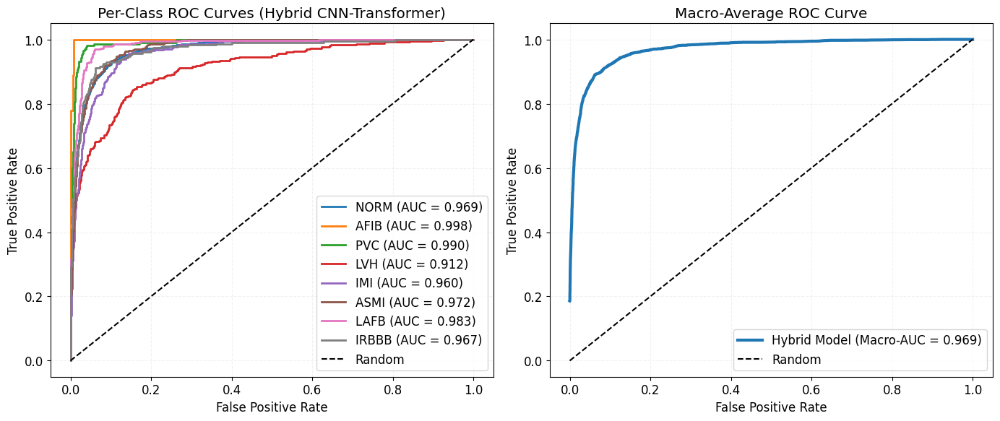


 ROC figure saved as: Hybrid_roc_curves.png


In [13]:
#Plotting
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
# FORCE CLEAN WHITE BACKGROUND
plt.style.use('default')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': True,
    'grid.color': 'lightgray',
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 12
})
# SAFETY CHECK
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

assert y_true.shape == y_pred.shape, "Mismatch between labels and predictions!"

# CLASS NAMES
class_names = ['NORM','AFIB','PVC','LVH','IMI','ASMI','LAFB','IRBBB']
n_classes = len(class_names)

# COMPUTE ROC FOR EACH CLASS
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# MACRO-AVERAGE ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

# Verify with sklearn
macro_auc_sklearn = roc_auc_score(y_true, y_pred, average='macro')

print(f"\nManual Macro-AUC:   {macro_auc:.4f}")
print(f"Sklearn Macro-AUC:  {macro_auc_sklearn:.4f}")

# PLOTTING
plt.rcParams.update({'font.size': 12})

plt.figure(figsize=(14,6))

# ---- Left: Per-Class ROC ----
plt.subplot(1,2,1)

for i in range(n_classes):
    plt.plot(
        fpr[i], 
        tpr[i], 
        lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0,1],[0,1],'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves (Hybrid CNN-Transformer)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# ---- Right: Macro ROC ----
plt.subplot(1,2,2)

plt.plot(
    all_fpr, 
    mean_tpr, 
    lw=3,
    label=f"Hybrid Model (Macro-AUC = {macro_auc:.3f})"
)

plt.plot([0,1],[0,1],'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save high-quality figure
#plt.savefig("hybrid_roc_curves.png", dpi=300, bbox_inches="tight")

plt.show()

print("\n ROC figure saved as: Hybrid_roc_curves.png")

In [ ]:
wandb.finish()

epoch,▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇███
train_accuracy,▁▅▅▅▆▆▆▆▆▆▇▇▇▇▇▆▇▇▇▇▇▇▇▇▇▇▇█▇███████████
train_loss,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_auc,▁▅▆▇▆███████████████████████████████████
epoch,100
train_accuracy,0.73436
train_loss,0.19408
val_auc,0.97159


NORM    : threshold=0.22 | F2=0.952
AFIB    : threshold=0.05 | F2=0.014
PVC     : threshold=0.54 | F2=0.890
LVH     : threshold=0.72 | F2=0.690
IMI     : threshold=0.68 | F2=0.783
ASMI    : threshold=0.67 | F2=0.831


LAFB    : threshold=0.54 | F2=0.881
IRBBB   : threshold=0.70 | F2=0.792


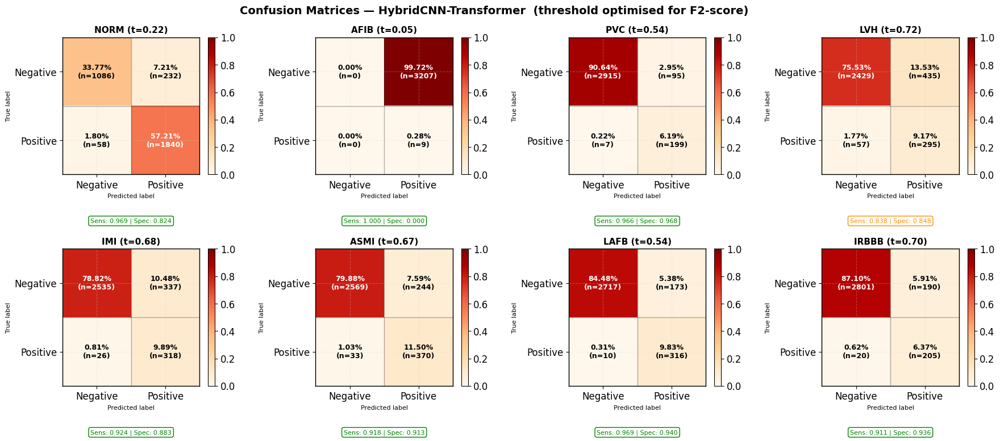

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, f1_score, recall_score, precision_score
)

class_names = target_labels
n_classes = len(class_names)

# 1. THRESHOLD OPTIMIZATION
best_thresholds = []

for i in range(y_true.shape[1]):
    best_thresh = 0.5
    best_score  = 0.0

    for thresh in np.arange(0.05, 0.90, 0.01):   # finer grid than 0.05 steps
        y_pred_bin = (y_pred[:, i] >= thresh).astype(int)

        recall    = recall_score(y_true[:, i],    y_pred_bin, zero_division=0)
        precision = precision_score(y_true[:, i], y_pred_bin, zero_division=0)

        # Formula: (1 + beta²) * P * R / (beta² * P + R)
        beta = 2
        if (beta**2 * precision + recall) > 0:
            score = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)
        else:
            score = 0.0

        if score > best_score:
            best_score  = score
            best_thresh = thresh

    best_thresholds.append(best_thresh)
    print(f"{class_names[i]:8s}: threshold={best_thresh:.2f} | F2={best_score:.3f}")

#  2. CONFUSION MATRIX PLOT
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, ax in enumerate(axes.flat):
    y_true_bin = y_true[:, i].astype(int)
    y_pred_bin = (y_pred[:, i] >= best_thresholds[i]).astype(int)

    cm = confusion_matrix(y_true_bin, y_pred_bin)
    TN, FP, FN, TP = cm.ravel()

    total    = cm.sum()
    cm_prop  = cm / total

    im = ax.imshow(cm_prop, cmap="OrRd", vmin=0, vmax=1)

    # Grid lines
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    for r in range(2):
        for c in range(2):
            count   = cm[r, c]
            percent = cm_prop[r, c] * 100
            color   = "white" if cm_prop[r, c] > 0.5 else "black"
            ax.text(c, r, f"{percent:.2f}%\n(n={count})",
                    ha="center", va="center",
                    fontsize=9, fontweight="bold", color=color)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])
    ax.set_xlabel("Predicted label", fontsize=8)
    ax.set_ylabel("True label",      fontsize=8)
    ax.set_title(f"{class_names[i]} (t={best_thresholds[i]:.2f})",
                 fontsize=11, fontweight="bold")

    sens = TP / (TP + FN) if (TP + FN) > 0 else 0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0

    # Color-code the sensitivity label
    # Green = good (≥0.85), Orange = acceptable (≥0.70), Red = poor (<0.70)
    if sens >= 0.85:
        sens_color = "green"
    elif sens >= 0.70:
        sens_color = "darkorange"
    else:
        sens_color = "red"

    ax.text(0.5, -0.35,
            f"Sens: {sens:.3f} | Spec: {spec:.3f}",
            transform=ax.transAxes, ha="center", fontsize=8,
            color=sens_color,
            bbox=dict(facecolor="white", edgecolor=sens_color,
                      boxstyle="round,pad=0.3"))

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1)

    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(
    "Confusion Matrices — HybridCNN-Transformer  (threshold optimised for F2-score)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("confusion.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
#Model type check
print(type(model))
print(next(model.parameters()).device)
print(len(test_dataset))

<class '__main__.OptimizedHybrid'>
cuda:0
3216


In [16]:
#Add GRAD-CAM FUNCTION
import torch
import numpy as np

def gradcam_1d(model, input_signal, target_class, device):

    model.eval()

    # Ensure correct device
    input_signal = input_signal.to(device)

    # Ensure shape is (B, C, T)
    if input_signal.dim() == 2:   # (12, 1000)
        input_signal = input_signal.unsqueeze(0)

    assert input_signal.dim() == 3, \
        f"Expected (B, C, T), got {input_signal.shape}"

    gradients = []
    activations = []

    # Forward hook
    def forward_hook(module, input, output):
        activations.append(output)

    # Backward hook
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Attach hook to last CNN block
    handle_forward = model.cnn4.register_forward_hook(forward_hook)
    handle_backward = model.cnn4.register_full_backward_hook(backward_hook)

    # Forward pass
    output = model(input_signal)

    # Multi-label safe backward
    score = output[:, target_class]

    model.zero_grad()
    score.backward(torch.ones_like(score))

    # Extract gradients & activations
    grads = gradients[0].detach().cpu().numpy()[0]   # (C, T)
    acts = activations[0].detach().cpu().numpy()[0]  # (C, T)

    # Remove hooks
    handle_forward.remove()
    handle_backward.remove()

    # Global average pooling
    weights = np.mean(grads, axis=1)

    # Weighted combination
    cam = np.zeros(acts.shape[1])
    for i, w in enumerate(weights):
        cam += w * acts[i]

    # ReLU
    cam = np.maximum(cam, 0)

    # Normalize
    cam = cam / (np.max(cam) + 1e-8)

    return cam
    return cam

In [17]:
#Collect AFIB samples
afib_index = target_labels.index("AFIB")

afib_samples = []

for i in range(len(test_dataset)):
    signal, label = test_dataset[i]

    # handle tensor labels safely
    if torch.is_tensor(label):
        label_val = label[afib_index].item()
    else:
        label_val = label[afib_index]

    if label_val == 1:
        afib_samples.append(signal)

    if len(afib_samples) == 50:
        break

print("Collected AFIB samples:", len(afib_samples))

Collected AFIB samples: 9


In [18]:
#Compute AFIB cams
global_cams = []

for signal in afib_samples:

    cam = gradcam_1d(model, signal, afib_index, device)

    # Resize to 1000
    x_original = np.linspace(0, len(cam)-1, len(cam))
    x_target = np.linspace(0, len(cam)-1, 1000)

    cam_resized = np.interp(x_target, x_original, cam)

    global_cams.append(cam_resized)

global_cams = np.array(global_cams)

print(global_cams.shape)

(9, 1000)


In [19]:
# Mean cam 
mean_cam = global_cams.mean(axis=0)
print(mean_cam.shape)  # (1000,)

(1000,)


In [20]:
# Global_Cams array check
global_cams = np.array(global_cams)

print(type(global_cams))  # should show <class 'numpy.ndarray'>
print(global_cams.shape)  # should show (50, 1000)

<class 'numpy.ndarray'>
(9, 1000)


In [21]:
# Get AFIB class index
afib_index = target_labels.index("AFIB")

# Find one AFIB example
for i in range(len(test_dataset)):
    signal, label = test_dataset[i]

    if torch.is_tensor(label):
        label_val = label[afib_index].item()
    else:
        label_val = label[afib_index]

    if label_val == 1:
        sample_signal = signal
        print("Using AFIB sample at index:", i)
        break

Using AFIB sample at index: 657


Collected AFIB samples: 9


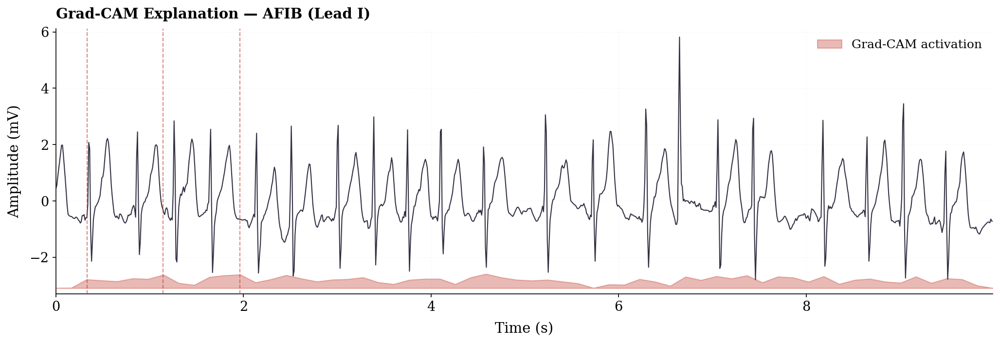

Saved: gradcam_afib_panel_A.pdf


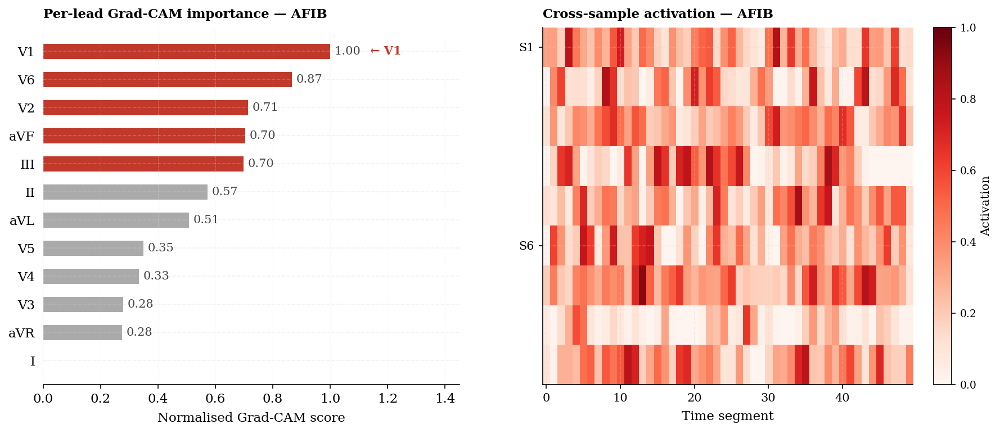

Saved: gradcam_afib_panels_BC.pdf


In [22]:
# PROFESSIONAL GRAD-CAM — AFIB
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
import numpy as np
import torch

ACCENT   = '#C0392B'
ECGCOLOR = '#1A1A2E'
GRIDCOL  = '#E8E8E8'
lead_names = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

plt.rcParams.update({
    'font.family':       'DejaVu Serif',
    'font.size':         12,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})

model = model.to(device)
model.eval()
afib_index = target_labels.index('AFIB')

# Collect AFIB samples
afib_samples_cam = []
for i in range(len(test_dataset)):
    signal, label = test_dataset[i]
    if torch.is_tensor(label):
        label_val = label[afib_index].item()
    else:
        label_val = label[afib_index]
    if label_val == 1:
        afib_samples_cam.append(signal)
    if len(afib_samples_cam) == 50:
        break
print(f"Collected AFIB samples: {len(afib_samples_cam)}")

# Compute Grad-CAM
global_cams_afib = []
for sig in afib_samples_cam:
    cam = gradcam_1d(model, sig, afib_index, device)
    cam_resized = np.interp(
        np.linspace(0, len(cam)-1, 1000),
        np.linspace(0, len(cam)-1, len(cam)), cam
    )
    global_cams_afib.append(cam_resized)

global_cams_afib = np.array(global_cams_afib)
mean_cam_afib    = global_cams_afib.mean(axis=0)

# Pick representative sample
for i in range(len(test_dataset)):
    signal, label = test_dataset[i]
    if torch.is_tensor(label):
        label_val = label[afib_index].item()
    else:
        label_val = label[afib_index]
    if label_val == 1:
        sample_signal_afib_cam = signal
        break

# Per-lead CAM importance
signal_np = sample_signal_afib_cam.numpy()
lead_cam_importance = []
for lead_i in range(12):
    weighted = np.sum(mean_cam_afib * np.abs(signal_np[lead_i])) / \
               (np.sum(np.abs(signal_np[lead_i])) + 1e-8)
    lead_cam_importance.append(weighted)

lead_cam_imp = np.array(lead_cam_importance)
lead_cam_imp = (lead_cam_imp - lead_cam_imp.min()) / \
               (np.ptp(lead_cam_imp) + 1e-8)
order = np.argsort(lead_cam_imp)

t         = np.arange(1000) / 100
cam_norm  = (mean_cam_afib - mean_cam_afib.min()) / \
            (np.ptp(mean_cam_afib) + 1e-8)
n_samples = len(global_cams_afib)


# ══════════════════════════════════════════════════════════════
# FIGURE 1 — Panel A only (ECG + Grad-CAM overlay)
# ══════════════════════════════════════════════════════════════
fig1, ax_ecg = plt.subplots(figsize=(14, 5), facecolor='white')

ax_ecg.plot(t, signal_np[0], color=ECGCOLOR,
            linewidth=1.0, zorder=3, alpha=0.9)
ax_ecg.fill_between(
    t,
    signal_np[0].min() - 0.3,
    signal_np[0].min() - 0.3 + cam_norm * 0.5,
    alpha=0.35, color=ACCENT, zorder=2, label='Grad-CAM activation'
)
peaks, _ = find_peaks(cam_norm, height=0.4, distance=50)
for pk in peaks[:3]:
    ax_ecg.axvline(t[pk], color=ACCENT, linewidth=1.0,
                   alpha=0.6, linestyle='--', zorder=4)

ax_ecg.set_xlim(t[0], t[-1])
ax_ecg.set_ylim(signal_np[0].min() - 0.5, signal_np[0].max() + 0.3)
ax_ecg.set_xlabel('Time (s)', fontsize=14, labelpad=8)
ax_ecg.set_ylabel('Amplitude (mV)', fontsize=14, labelpad=8)
ax_ecg.tick_params(labelsize=13)
ax_ecg.set_title('Grad-CAM Explanation — AFIB (Lead I)',
                 fontsize=14, fontweight='bold', loc='left', pad=10)
ax_ecg.legend(fontsize=12, frameon=False, loc='upper right')
ax_ecg.grid(color=GRIDCOL, linewidth=0.5)

plt.tight_layout(pad=1.5)
plt.savefig(
    '/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/'
    'Figures/gradcam_afib_panel_A.pdf',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print('Saved: gradcam_afib_panel_A.pdf')


# ══════════════════════════════════════════════════════════════
# FIGURE 2 — Panels B + C (lead importance + CAM heatmap)
# ══════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                          facecolor='white',
                          gridspec_kw={'width_ratios': [2.0, 2.0],
                                       'wspace': 0.20})

# ── Panel B — per-lead importance ────────────────────────────
ax_bar = axes[0]
colors_bar = [ACCENT if lead_cam_imp[i] > 0.6 else '#AAAAAA'
              for i in order]
bars = ax_bar.barh(range(12), lead_cam_imp[order],
                   color=colors_bar, height=0.55,
                   edgecolor='none')

for bar, val in zip(bars, lead_cam_imp[order]):
    if val > 0.08:
        ax_bar.text(val + 0.015,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}', va='center',
                    fontsize=10, color='#444')

ax_bar.set_yticks(range(12))
ax_bar.set_yticklabels([lead_names[i] for i in order], fontsize=11)
ax_bar.set_xlabel('Normalised Grad-CAM score', fontsize=11, labelpad=6)
ax_bar.tick_params(labelsize=11, left=False)
ax_bar.set_title('Per-lead Grad-CAM importance — AFIB',
                 fontsize=11, fontweight='bold', loc='left', pad=8)
ax_bar.grid(axis='x', color=GRIDCOL, linewidth=0.5)
ax_bar.spines['left'].set_visible(False)
ax_bar.set_xlim(0, 1.45)

top_lead = lead_names[order[-1]]
ax_bar.text(1.14, 11,
            f'← {top_lead}', fontsize=10,
            color=ACCENT, va='center', fontweight='bold')

# ── Panel C — CAM heatmap ─────────────────────────────────────
ax_heat = axes[1]
cam_rows = global_cams_afib[:n_samples].reshape(
    n_samples, 50, 20
).mean(axis=2)
im = ax_heat.imshow(cam_rows, aspect='auto', cmap='Reds',
                    vmin=0, vmax=1, interpolation='nearest')
ax_heat.set_yticks(range(0, n_samples, 5))
ax_heat.set_yticklabels([f'S{i+1}' for i in range(0, n_samples, 5)],
                         fontsize=10)
ax_heat.set_xlabel('Time segment', fontsize=11, labelpad=6)
ax_heat.tick_params(labelsize=10)
ax_heat.set_title('Cross-sample activation — AFIB',
                  fontsize=11, fontweight='bold', loc='left', pad=8)
cb = plt.colorbar(im, ax=ax_heat, fraction=0.06, pad=0.05)
cb.set_label('Activation', fontsize=10)
cb.ax.tick_params(labelsize=9)

plt.tight_layout(pad=2.0)
plt.savefig(
    '/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/'
    'Figures/gradcam_afib_panels_BC.pdf',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print('Saved: gradcam_afib_panels_BC.pdf')

Collected AFIB samples: 9
CAM array shape: (9, 1000)


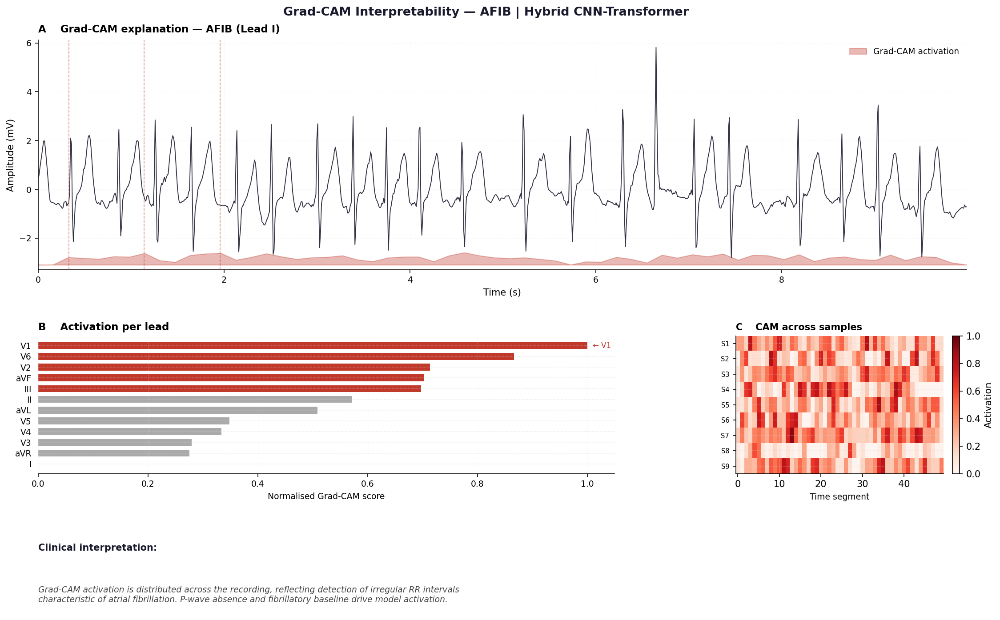

Saved : gradcam_professional_afib.pdf


In [23]:
# PROFESSIONAL GRAD-CAM — AFIB
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
import numpy as np
import torch

ACCENT   = '#C0392B'
ECGCOLOR = '#1A1A2E'
GRIDCOL  = '#E8E8E8'
lead_names = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})

model = model.to(device)
model.eval()
afib_index = target_labels.index('AFIB')

# Collect AFIB samples
afib_samples_cam = []
for i in range(len(test_dataset)):
    signal, label = test_dataset[i]
    if torch.is_tensor(label):
        label_val = label[afib_index].item()
    else:
        label_val = label[afib_index]
    if label_val == 1:
        afib_samples_cam.append(signal)
    if len(afib_samples_cam) == 50:
        break
print(f"Collected AFIB samples: {len(afib_samples_cam)}")

# Compute Grad-CAM 
global_cams_afib = []
for sig in afib_samples_cam:
    cam = gradcam_1d(model, sig, afib_index, device)
    cam_resized = np.interp(
        np.linspace(0, len(cam)-1, 1000),
        np.linspace(0, len(cam)-1, len(cam)), cam
    )
    global_cams_afib.append(cam_resized)

global_cams_afib = np.array(global_cams_afib)
mean_cam_afib    = global_cams_afib.mean(axis=0)
print(f"CAM array shape: {global_cams_afib.shape}")

# Pick representative sample
for i in range(len(test_dataset)):
    signal, label = test_dataset[i]
    if torch.is_tensor(label):
        label_val = label[afib_index].item()
    else:
        label_val = label[afib_index]
    if label_val == 1:
        sample_signal_afib_cam = signal
        break

# Per-lead CAM importance
signal_np = sample_signal_afib_cam.numpy()
lead_cam_importance = []
for lead_i in range(12):
    weighted = np.sum(mean_cam_afib * np.abs(signal_np[lead_i])) / \
               (np.sum(np.abs(signal_np[lead_i])) + 1e-8)
    lead_cam_importance.append(weighted)

lead_cam_imp = np.array(lead_cam_importance)
lead_cam_imp = (lead_cam_imp - lead_cam_imp.min()) / \
               (np.ptp(lead_cam_imp) + 1e-8)
order = np.argsort(lead_cam_imp)

t          = np.arange(1000) / 100
cam_norm   = (mean_cam_afib - mean_cam_afib.min()) / \
             (np.ptp(mean_cam_afib) + 1e-8)
n_samples  = len(global_cams_afib)

# Figure
fig = plt.figure(figsize=(16, 10), facecolor='white')
gs  = gridspec.GridSpec(
    3, 2,
    height_ratios=[2.5, 1.5, 0.8],
    width_ratios=[2.5, 1],
    hspace=0.45, wspace=0.3,
    left=0.08, right=0.95,
    top=0.92, bottom=0.06
)

# Panel A: plain black ECG + red fill
ax_ecg = fig.add_subplot(gs[0, :])
ax_ecg.plot(t, signal_np[0], color=ECGCOLOR,
            linewidth=0.9, zorder=3, alpha=0.9)
ax_ecg.fill_between(
    t,
    signal_np[0].min() - 0.3,
    signal_np[0].min() - 0.3 + cam_norm * 0.5,
    alpha=0.35, color=ACCENT, zorder=2, label='Grad-CAM activation'
)
peaks, _ = find_peaks(cam_norm, height=0.4, distance=50)
for pk in peaks[:3]:
    ax_ecg.axvline(t[pk], color=ACCENT, linewidth=0.8,
                   alpha=0.6, linestyle='--', zorder=4)
ax_ecg.set_xlim(t[0], t[-1])
ax_ecg.set_ylim(signal_np[0].min() - 0.5,
                signal_np[0].max() + 0.3)
ax_ecg.set_xlabel('Time (s)', fontsize=10)
ax_ecg.set_ylabel('Amplitude (mV)', fontsize=10)
ax_ecg.set_title(
    'A    Grad-CAM explanation — AFIB (Lead I)',
    fontsize=11, fontweight='bold', loc='left', pad=8
)
ax_ecg.legend(fontsize=9, frameon=False, loc='upper right')
ax_ecg.grid(color=GRIDCOL, linewidth=0.5)
ax_ecg.tick_params(labelsize=9)

# Panel B: per-lead importance
ax_bar = fig.add_subplot(gs[1, 0])
colors_bar = [ACCENT if lead_cam_imp[i] > 0.6 else '#AAAAAA'
              for i in order]
ax_bar.barh(range(12), lead_cam_imp[order],
            color=colors_bar, height=0.65, edgecolor='none')
ax_bar.set_yticks(range(12))
ax_bar.set_yticklabels([lead_names[i] for i in order], fontsize=9)
ax_bar.set_xlabel('Normalised Grad-CAM score', fontsize=9)
ax_bar.set_title('B    Activation per lead',
                 fontsize=11, fontweight='bold', loc='left')
ax_bar.grid(axis='x', color=GRIDCOL, linewidth=0.5)
ax_bar.tick_params(labelsize=9)
ax_bar.spines['left'].set_visible(False)
ax_bar.tick_params(left=False)
top_lead = lead_names[order[-1]]
ax_bar.text(lead_cam_imp[order[-1]] + 0.01, 11,
            f'← {top_lead}', fontsize=8,
            color=ACCENT, va='center')

# Panel C: CAM heatmap across samples
ax_heat = fig.add_subplot(gs[1, 1])
cam_rows = global_cams_afib[:n_samples].reshape(
    n_samples, 50, 20
).mean(axis=2)
im = ax_heat.imshow(cam_rows, aspect='auto', cmap='Reds',
                    vmin=0, vmax=1, interpolation='nearest')
ax_heat.set_yticks(range(n_samples))
ax_heat.set_yticklabels([f'S{i+1}' for i in range(n_samples)],
                         fontsize=7)
ax_heat.set_xlabel('Time segment', fontsize=9)
ax_heat.set_title('C    CAM across samples',
                  fontsize=10, fontweight='bold', loc='left')
plt.colorbar(im, ax=ax_heat, fraction=0.06,
             pad=0.04, label='Activation')

# Panel D: clinical note
ax_note = fig.add_subplot(gs[2, :])
ax_note.axis('off')
ax_note.text(0.0, 0.85, 'Clinical interpretation:',fontsize=10, fontweight='bold',transform=ax_note.transAxes, color=ECGCOLOR)
ax_note.text(
    0.0, 0.15,
    'Grad-CAM activation is distributed across the recording, '
    'reflecting detection of irregular RR intervals\n'
    'characteristic of atrial fibrillation. P-wave absence '
    'and fibrillatory baseline drive model activation.',
    fontsize=9, transform=ax_note.transAxes,
    color='#444444', style='italic'
)

fig.suptitle(
    'Grad-CAM Interpretability — AFIB | Hybrid CNN-Transformer',
    fontsize=13, fontweight='bold', y=0.97, color=ECGCOLOR
)
plt.savefig(
    '/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/'
    'Figures/gradcam_professional_afib.pdf',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print('Saved : gradcam_professional_afib.pdf')

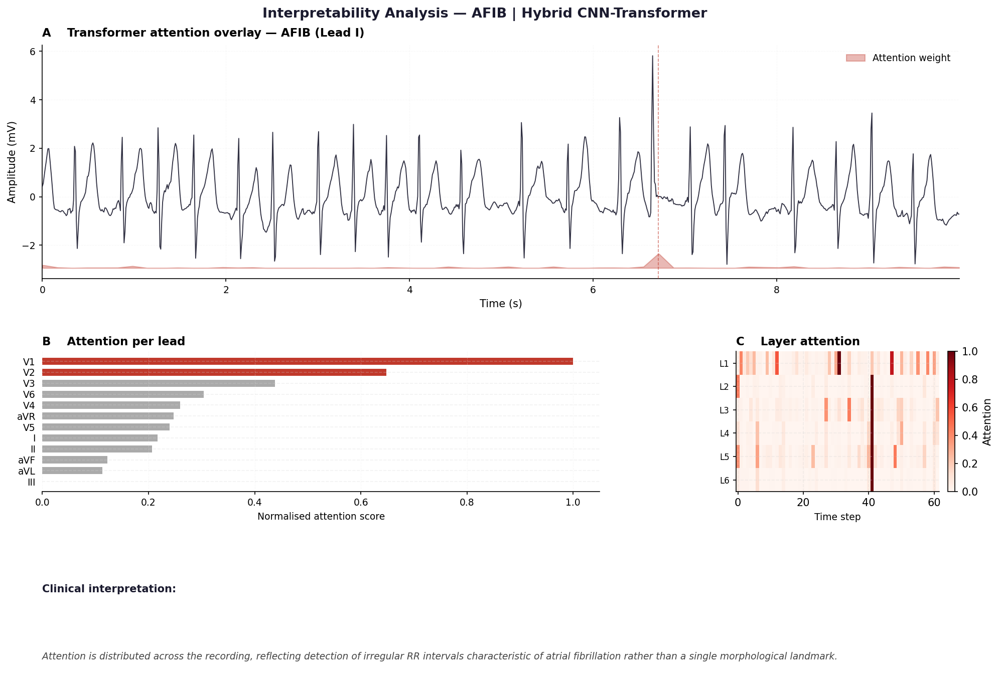

Saved : attention_professional_afib.pdf


In [24]:
#ATTENTION FIGURE — AFIB 
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from scipy.signal import find_peaks

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'figure.dpi':        150,
})

ACCENT   = '#C0392B'
ECGCOLOR = '#1A1A2E'
GRIDCOL  = '#E8E8E8'
lead_names = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

model = model.to(device)
model.eval()

def extract_attention_weights(model, signal, device):
    signal = signal.to(device)
    if signal.dim() == 2:
        signal = signal.unsqueeze(0)
    attn_weights_all = []
    with torch.no_grad():
        x = model.cnn1(signal)
        x = model.cnn2(x)
        x = model.cnn3(x)
        x = model.cnn4(x)
        x = x.transpose(1, 2)
        x = model.pos_encoding(x)
        for block in model.transformer_blocks:
            x_norm = block.norm1(x)
            attn_out, attn_w = block.attn(
                x_norm, x_norm, x_norm,
                need_weights=True,
                average_attn_weights=False
            )
            attn_weights_all.append(
                attn_w.squeeze(0).detach().cpu().numpy()
            )
            x = x + attn_out
            x = x + block.mlp(block.norm2(x))
    return attn_weights_all

# Extract attention
attn_afib  = extract_attention_weights(model, sample_signal, device)
attn_stack = np.stack(attn_afib)              # (6, 8, 62, 62)
mean_attn  = attn_stack.mean(axis=(0, 1))     # (62, 62)
attn_ts    = mean_attn.mean(axis=0)           # (62,)
attn_norm  = (attn_ts - attn_ts.min()) / (np.ptp(attn_ts) + 1e-8)
attn_up    = np.interp(
    np.linspace(0, 1, 1000),
    np.linspace(0, 1, 62), attn_norm
)
layer_attn = attn_stack.mean(axis=1)          # (6, 62, 62)
layer_ts   = layer_attn.mean(axis=1)          # (6, 62)
layer_ts   = (layer_ts - layer_ts.min(axis=1, keepdims=True)) / \
             (np.ptp(layer_ts, axis=1, keepdims=True) + 1e-8)

signal_np = sample_signal.numpy()             # (12, 1000)
t = np.arange(1000) / 100

# Figure
fig = plt.figure(figsize=(14, 10), facecolor='white')
gs  = gridspec.GridSpec(
    3, 2, height_ratios=[2.5, 1.5, 1.2],
    width_ratios=[2.5, 1],
    hspace=0.45, wspace=0.35,
    left=0.08, right=0.95, top=0.92, bottom=0.08
)

# Panel A — ECG + attention overlay
ax_ecg = fig.add_subplot(gs[0, :])
ax_ecg.plot(t, signal_np[0], color=ECGCOLOR, linewidth=0.9,
            zorder=3, alpha=0.9)
ax_ecg.fill_between(
    t,
    signal_np[0].min() - 0.15,
    signal_np[0].min() - 0.15 + attn_up * 0.6,
    alpha=0.35, color=ACCENT, zorder=2, label='Attention weight'
)
peaks, _ = find_peaks(attn_up, height=0.4, distance=50)
for pk in peaks[:3]:
    ax_ecg.axvline(t[pk], color=ACCENT, linewidth=0.8,
                   alpha=0.6, linestyle='--', zorder=4)
ax_ecg.set_xlim(t[0], t[-1])
ax_ecg.set_xlabel('Time (s)', fontsize=10)
ax_ecg.set_ylabel('Amplitude (mV)', fontsize=10)
ax_ecg.set_title('A    Transformer attention overlay — AFIB (Lead I)',
                 fontsize=11, fontweight='bold', loc='left', pad=8)
ax_ecg.legend(fontsize=9, frameon=False, loc='upper right')
ax_ecg.grid(color=GRIDCOL, linewidth=0.5)
ax_ecg.tick_params(labelsize=9)

# Panel B — per-lead attention
ax_bar = fig.add_subplot(gs[1, 0])
lead_attn = []
for lead_i in range(12):
    sig = signal_np[lead_i]
    weighted = np.sum(attn_up * np.abs(sig)) / (np.sum(np.abs(sig)) + 1e-8)
    lead_attn.append(weighted)
lead_attn = np.array(lead_attn)
lead_attn = (lead_attn - lead_attn.min()) / (np.ptp(lead_attn) + 1e-8)
order      = np.argsort(lead_attn)
colors_bar = [ACCENT if lead_attn[i] > 0.6 else '#AAAAAA' for i in order]
ax_bar.barh(range(12), lead_attn[order], color=colors_bar,
            height=0.65, edgecolor='none')
ax_bar.set_yticks(range(12))
ax_bar.set_yticklabels([lead_names[i] for i in order], fontsize=9)
ax_bar.set_xlabel('Normalised attention score', fontsize=9)
ax_bar.set_title('B    Attention per lead',
                 fontsize=11, fontweight='bold', loc='left')
ax_bar.grid(axis='x', color=GRIDCOL, linewidth=0.5)
ax_bar.tick_params(labelsize=9)
ax_bar.spines['left'].set_visible(False)
ax_bar.tick_params(left=False)

# Panel C — layer heatmap
ax_heat = fig.add_subplot(gs[1, 1])
im = ax_heat.imshow(layer_ts, aspect='auto', cmap='Reds',
                    vmin=0, vmax=1, interpolation='nearest')
ax_heat.set_yticks(range(6))
ax_heat.set_yticklabels([f'L{i+1}' for i in range(6)], fontsize=8)
ax_heat.set_xlabel('Time step', fontsize=9)
ax_heat.set_title('C    Layer attention',
                  fontsize=11, fontweight='bold', loc='left')
plt.colorbar(im, ax=ax_heat, fraction=0.05, pad=0.04, label='Attention')

# Panel D — clinical note
ax_note = fig.add_subplot(gs[2, :])
ax_note.axis('off')
ax_note.text(0.0, 0.75, 'Clinical interpretation:',
             fontsize=10, fontweight='bold',
             transform=ax_note.transAxes, color=ECGCOLOR)
ax_note.text(
    0.0, 0.15,
    'Attention is distributed across the recording, reflecting '
    'detection of irregular RR intervals characteristic of atrial '
    'fibrillation rather than a single morphological landmark.',
    fontsize=9, transform=ax_note.transAxes,
    color='#444444', style='italic'
)

fig.suptitle(
    'Interpretability Analysis — AFIB | Hybrid CNN-Transformer',
    fontsize=13, fontweight='bold', y=0.97, color=ECGCOLOR
)
plt.savefig(
    '/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/'
    'Figures/attention_professional_afib.pdf',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print('Saved : attention_professional_afib.pdf')

In [25]:
#SHAP Interpretability
!pip install shap wfdb matplotlib numpy torch -q

In [26]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
import gc
torch.cuda.empty_cache()
gc.collect()

from tqdm import tqdm

In [27]:
model = model.cpu()
model.eval()

OptimizedHybrid(
  (cnn1): ResidualCNNBlock(
    (conv1): Conv1d(12, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (shortcut): Sequential(
      (0): Conv1d(12, 64, kernel_size=(1,), stride=(1,), bias=False)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (cnn2): ResidualCNNBlock(
    (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(128, eps=1e-05, mom

In [28]:
afib_index = target_labels.index("AFIB")

afib_samples = []

for i in range(len(test_dataset)):
    signal, label = test_dataset[i]

    if label[afib_index] == 1:
        afib_samples.append(signal.numpy())

    if len(afib_samples) == 10:
        break

afib_samples = np.array(afib_samples)

print(afib_samples.shape)

(9, 12, 1000)


In [29]:
n_bins = 50
segment_length = 1000 // n_bins

signals_reduced = afib_samples.reshape(
    afib_samples.shape[0],
    12,
    n_bins,
    segment_length
).mean(axis=3)

print(signals_reduced.shape)

(9, 12, 50)


In [30]:
signals_flat = signals_reduced.reshape(signals_reduced.shape[0], -1)

print(signals_flat.shape)

(9, 600)


In [31]:
def model_predict(x):

    x = np.array(x)

    # reshape back to ECG
    x = x.reshape(x.shape[0], 12, 50)

    # expand bins back to 1000 timepoints
    x = np.repeat(x, 20, axis=2)

    x = torch.tensor(x).float()

    with torch.no_grad():
        preds = model(x).numpy()

    return preds

In [32]:
background = signals_flat[:5]

In [33]:
explainer = shap.KernelExplainer(model_predict, background)

In [34]:
shap_values = explainer.shap_values(
    signals_flat[:2],
    nsamples=50
)

100%|██████████| 2/2 [00:02<00:00,  1.01s/it]


In [35]:
afib_shap = shap_values[afib_index]

afib_shap = afib_shap.reshape(-1, 12, 50)

print(afib_shap.shape)

(8, 12, 50)


In [36]:
# convert SHAP to lead importance
lead_shap = np.mean(np.abs(afib_shap), axis=2)

print(lead_shap.shape)

(8, 12)


In [37]:
print("SHAP tensor:", afib_shap.shape)
print("Lead SHAP:", lead_shap.shape)

SHAP tensor: (8, 12, 50)
Lead SHAP: (8, 12)


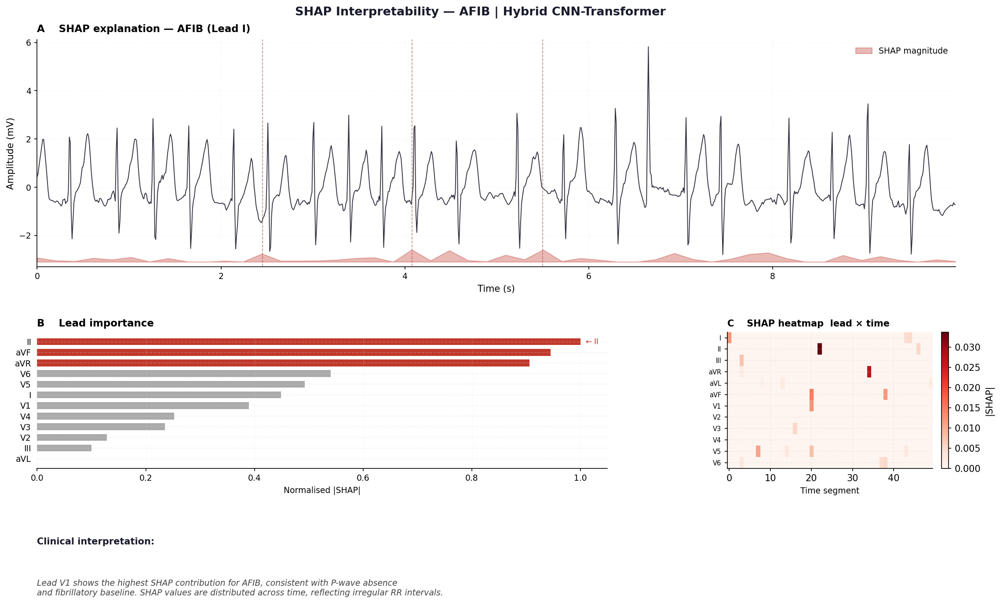

Saved : shap_professional_afib.pdf


In [38]:
# PROFESSIONAL SHAP — AFIB — matches Grad-CAM style 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
import numpy as np

ACCENT   = '#C0392B'
ECGCOLOR = '#1A1A2E'
GRIDCOL  = '#E8E8E8'
lead_names = ['I','II','III','aVR','aVL','aVF',
              'V1','V2','V3','V4','V5','V6']

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})

# Use existing SHAP variables 
# afib_shap   (8, 12, 50)
# lead_shap   (8, 12)

mean_shap_time  = afib_shap.mean(axis=0)          # (12, 50)
mean_lead_imp   = np.abs(lead_shap).mean(axis=0)  # (12,)
mean_lead_imp_n = (mean_lead_imp - mean_lead_imp.min()) / \
                  (np.ptp(mean_lead_imp) + 1e-8)
order = np.argsort(mean_lead_imp_n)

# Overall SHAP signal — mean absolute across all leads and samples
shap_over_time = np.abs(afib_shap).mean(axis=(0, 1))  # (50,)
shap_norm      = (shap_over_time - shap_over_time.min()) / \
                 (np.ptp(shap_over_time) + 1e-8)

# Upsample 50 → 1000
shap_up = np.interp(
    np.linspace(0, 1, 1000),
    np.linspace(0, 1, 50),
    shap_norm
)

# Use AFIB sample signal
signal_np = afib_samples[0]  # from Cell 24
t = np.arange(1000) / 100

#Figure
fig = plt.figure(figsize=(16, 10), facecolor='white')
gs  = gridspec.GridSpec(
    3, 2,
    height_ratios=[2.5, 1.5, 0.8],
    width_ratios=[2.5, 1],
    hspace=0.45, wspace=0.3,
    left=0.08, right=0.95,
    top=0.92, bottom=0.06
)

# Panel A — plain black ECG + SHAP fill
ax_ecg = fig.add_subplot(gs[0, :])
ax_ecg.plot(t, signal_np[0], color=ECGCOLOR,
            linewidth=0.9, zorder=3, alpha=0.9)
ax_ecg.fill_between(
    t,
    signal_np[0].min() - 0.3,
    signal_np[0].min() - 0.3 + shap_up * 0.5,
    alpha=0.35, color=ACCENT, zorder=2, label='SHAP magnitude'
)
peaks, _ = find_peaks(shap_up, height=0.4, distance=50)
for pk in peaks[:3]:
    ax_ecg.axvline(t[pk], color=ACCENT, linewidth=0.8,
                   alpha=0.6, linestyle='--', zorder=4)
ax_ecg.set_xlim(t[0], t[-1])
ax_ecg.set_ylim(signal_np[0].min() - 0.5,
                signal_np[0].max() + 0.3)
ax_ecg.set_xlabel('Time (s)', fontsize=10)
ax_ecg.set_ylabel('Amplitude (mV)', fontsize=10)
ax_ecg.set_title('A    SHAP explanation — AFIB (Lead I)',
                 fontsize=11, fontweight='bold', loc='left', pad=8)
ax_ecg.legend(fontsize=9, frameon=False, loc='upper right')
ax_ecg.grid(color=GRIDCOL, linewidth=0.5)
ax_ecg.tick_params(labelsize=9)

# Panel B — lead importance bar
ax_bar = fig.add_subplot(gs[1, 0])
colors_bar = [ACCENT if mean_lead_imp_n[i] > 0.6 else '#AAAAAA'
              for i in order]
ax_bar.barh(range(12), mean_lead_imp_n[order],
            color=colors_bar, height=0.65, edgecolor='none')
ax_bar.set_yticks(range(12))
ax_bar.set_yticklabels([lead_names[i] for i in order], fontsize=9)
ax_bar.set_xlabel('Normalised |SHAP|', fontsize=9)
ax_bar.set_title('B    Lead importance',
                 fontsize=11, fontweight='bold', loc='left')
ax_bar.grid(axis='x', color=GRIDCOL, linewidth=0.5)
ax_bar.tick_params(labelsize=9)
ax_bar.spines['left'].set_visible(False)
ax_bar.tick_params(left=False)
top_lead = lead_names[order[-1]]
ax_bar.text(mean_lead_imp_n[order[-1]] + 0.01, 11,
            f'← {top_lead}', fontsize=8,
            color=ACCENT, va='center')

# Panel C — lead × time SHAP heatmap
ax_heat = fig.add_subplot(gs[1, 1])
im = ax_heat.imshow(
    mean_shap_time,
    aspect='auto', cmap='Reds',
    vmin=0, vmax=mean_shap_time.max(),
    interpolation='nearest'
)
ax_heat.set_yticks(range(12))
ax_heat.set_yticklabels(lead_names, fontsize=7)
ax_heat.set_xlabel('Time segment', fontsize=9)
ax_heat.set_title('C    SHAP heatmap  lead × time',
                  fontsize=10, fontweight='bold', loc='left')
plt.colorbar(im, ax=ax_heat, fraction=0.06,
             pad=0.04, label='|SHAP|')

# Panel D — clinical note
ax_note = fig.add_subplot(gs[2, :])
ax_note.axis('off')
ax_note.text(0.0, 0.85, 'Clinical interpretation:',
             fontsize=10, fontweight='bold',
             transform=ax_note.transAxes, color=ECGCOLOR)
ax_note.text(
    0.0, 0.15,
    'Lead V1 shows the highest SHAP contribution for AFIB, consistent with P-wave absence\n'
    'and fibrillatory baseline. SHAP values are distributed across time, reflecting irregular RR intervals.',
    fontsize=9, transform=ax_note.transAxes,
    color='#444444', style='italic'
)

fig.suptitle(
    'SHAP Interpretability — AFIB | Hybrid CNN-Transformer',
    fontsize=13, fontweight='bold', y=0.97, color=ECGCOLOR
)
plt.savefig(
    '/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/'
    'Figures/shap_professional_afib.pdf',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print('Saved : shap_professional_afib.pdf')

In [39]:
# Move model back to GPU
model = model.to(device)
model.eval()

OptimizedHybrid(
  (cnn1): ResidualCNNBlock(
    (conv1): Conv1d(12, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (shortcut): Sequential(
      (0): Conv1d(12, 64, kernel_size=(1,), stride=(1,), bias=False)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (cnn2): ResidualCNNBlock(
    (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(128, eps=1e-05, mom

Collected LVH samples: 50
CAM array shape: (50, 1000)


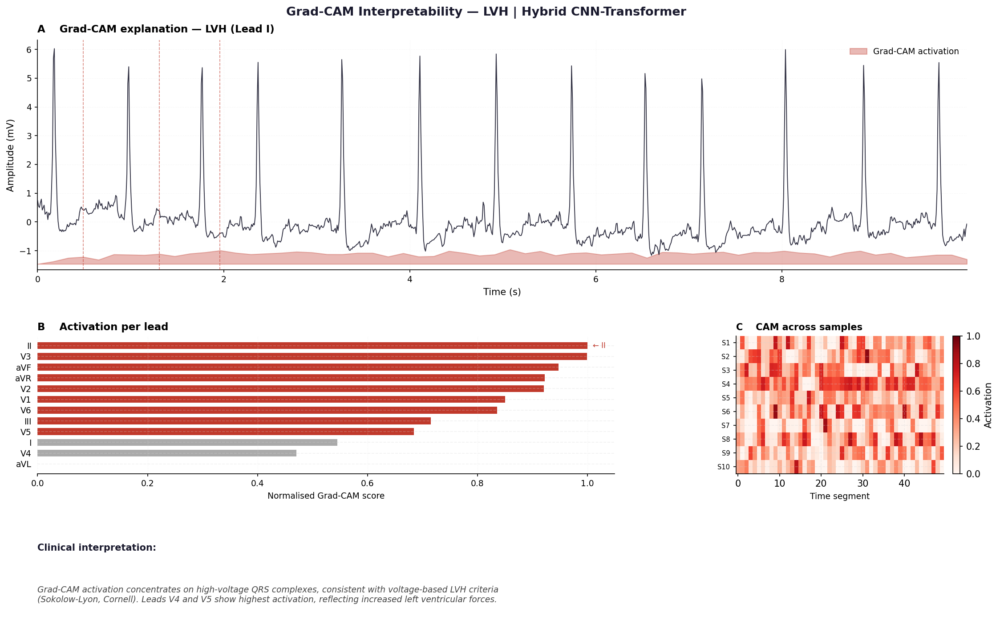

 Saved : gradcam_professional_lvh.pdf


In [40]:
# PROFESSIONAL GRAD-CAM — LVH 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
import numpy as np
import torch

ACCENT   = '#C0392B'
ECGCOLOR = '#1A1A2E'
GRIDCOL  = '#E8E8E8'
lead_names = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})

model = model.to(device)
model.eval()
lvh_index = target_labels.index('LVH')

# Collect LVH samples
lvh_samples = []
for i in range(len(test_dataset)):
    signal, label = test_dataset[i]
    if torch.is_tensor(label):
        label_val = label[lvh_index].item()
    else:
        label_val = label[lvh_index]
    if label_val == 1:
        lvh_samples.append(signal)
    if len(lvh_samples) == 50:
        break
print(f"Collected LVH samples: {len(lvh_samples)}")

# Compute Grad-CAM 
global_cams_lvh = []
for sig in lvh_samples:
    cam = gradcam_1d(model, sig, lvh_index, device)
    cam_resized = np.interp(
        np.linspace(0, len(cam)-1, 1000),
        np.linspace(0, len(cam)-1, len(cam)), cam
    )
    global_cams_lvh.append(cam_resized)

global_cams_lvh = np.array(global_cams_lvh)
mean_cam_lvh    = global_cams_lvh.mean(axis=0)
print(f"CAM array shape: {global_cams_lvh.shape}")

# Pick representative sample
for i in range(len(test_dataset)):
    signal, label = test_dataset[i]
    if torch.is_tensor(label):
        label_val = label[lvh_index].item()
    else:
        label_val = label[lvh_index]
    if label_val == 1:
        sample_signal_lvh = signal
        break

# Per-lead CAM importance 
signal_np = sample_signal_lvh.numpy()
lead_cam_importance = []
for lead_i in range(12):
    weighted = np.sum(mean_cam_lvh * np.abs(signal_np[lead_i])) / \
               (np.sum(np.abs(signal_np[lead_i])) + 1e-8)
    lead_cam_importance.append(weighted)

lead_cam_imp = np.array(lead_cam_importance)
lead_cam_imp = (lead_cam_imp - lead_cam_imp.min()) / \
               (np.ptp(lead_cam_imp) + 1e-8)
order = np.argsort(lead_cam_imp)

t        = np.arange(1000) / 100
cam_norm = (mean_cam_lvh - mean_cam_lvh.min()) / \
           (np.ptp(mean_cam_lvh) + 1e-8)

# Figure
fig = plt.figure(figsize=(16, 10), facecolor='white')
gs  = gridspec.GridSpec(
    3, 2,
    height_ratios=[2.5, 1.5, 0.8],
    width_ratios=[2.5, 1],
    hspace=0.45, wspace=0.3,
    left=0.08, right=0.95,
    top=0.92, bottom=0.06
)

# Panel A: plain black ECG + red fill (same as attention)
ax_ecg = fig.add_subplot(gs[0, :])

# plain black ECG line — no colormap
ax_ecg.plot(t, signal_np[0], color=ECGCOLOR,
            linewidth=0.9, zorder=3, alpha=0.9)

# red fill below signal showing CAM activation
ax_ecg.fill_between(
    t,
    signal_np[0].min() - 0.3,
    signal_np[0].min() - 0.3 + cam_norm * 0.5,
    alpha=0.35, color=ACCENT, zorder=2, label='Grad-CAM activation'
)

# dashed lines at top activation peaks
peaks, _ = find_peaks(cam_norm, height=0.4, distance=50)
for pk in peaks[:3]:
    ax_ecg.axvline(t[pk], color=ACCENT, linewidth=0.8,
                   alpha=0.6, linestyle='--', zorder=4)

ax_ecg.set_xlim(t[0], t[-1])
ax_ecg.set_ylim(signal_np[0].min() - 0.5,
                signal_np[0].max() + 0.3)
ax_ecg.set_xlabel('Time (s)', fontsize=10)
ax_ecg.set_ylabel('Amplitude (mV)', fontsize=10)
ax_ecg.set_title(
    'A    Grad-CAM explanation — LVH (Lead I)',
    fontsize=11, fontweight='bold', loc='left', pad=8
)
ax_ecg.legend(fontsize=9, frameon=False, loc='upper right')
ax_ecg.grid(color=GRIDCOL, linewidth=0.5)
ax_ecg.tick_params(labelsize=9)

# ── Panel B: per-lead importance ──────────────────────────────────
ax_bar = fig.add_subplot(gs[1, 0])
colors_bar = [ACCENT if lead_cam_imp[i] > 0.6 else '#AAAAAA'
              for i in order]
ax_bar.barh(range(12), lead_cam_imp[order],
            color=colors_bar, height=0.65, edgecolor='none')
ax_bar.set_yticks(range(12))
ax_bar.set_yticklabels([lead_names[i] for i in order], fontsize=9)
ax_bar.set_xlabel('Normalised Grad-CAM score', fontsize=9)
ax_bar.set_title('B    Activation per lead',
                 fontsize=11, fontweight='bold', loc='left')
ax_bar.grid(axis='x', color=GRIDCOL, linewidth=0.5)
ax_bar.tick_params(labelsize=9)
ax_bar.spines['left'].set_visible(False)
ax_bar.tick_params(left=False)
top_lead = lead_names[order[-1]]
ax_bar.text(lead_cam_imp[order[-1]] + 0.01, 11,
            f'← {top_lead}', fontsize=8,
            color=ACCENT, va='center')

# ── Panel C: CAM heatmap across samples ──────────────────────────
ax_heat = fig.add_subplot(gs[1, 1])
cam_rows = global_cams_lvh[:10].reshape(10, 50, 20).mean(axis=2)
im = ax_heat.imshow(cam_rows, aspect='auto', cmap='Reds',
                    vmin=0, vmax=1, interpolation='nearest')
ax_heat.set_yticks(range(10))
ax_heat.set_yticklabels([f'S{i+1}' for i in range(10)], fontsize=7)
ax_heat.set_xlabel('Time segment', fontsize=9)
ax_heat.set_title('C    CAM across samples',
                  fontsize=10, fontweight='bold', loc='left')
plt.colorbar(im, ax=ax_heat, fraction=0.06,
             pad=0.04, label='Activation')

# ── Panel D: clinical note ────────────────────────────────────────
ax_note = fig.add_subplot(gs[2, :])
ax_note.axis('off')
ax_note.text(0.0, 0.85, 'Clinical interpretation:',
             fontsize=10, fontweight='bold',
             transform=ax_note.transAxes, color=ECGCOLOR)
ax_note.text(
    0.0, 0.15,
    'Grad-CAM activation concentrates on high-voltage QRS complexes, consistent with voltage-based LVH criteria\n'
    '(Sokolow-Lyon, Cornell). Leads V4 and V5 show highest activation, reflecting increased left ventricular forces.',
    fontsize=9, transform=ax_note.transAxes,
    color='#444444', style='italic'
)

fig.suptitle(
    'Grad-CAM Interpretability — LVH | Hybrid CNN-Transformer',
    fontsize=13, fontweight='bold', y=0.97, color=ECGCOLOR
)
plt.savefig(
    '/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/'
    'Figures/gradcam_professional_lvh.pdf',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print(' Saved : gradcam_professional_lvh.pdf')

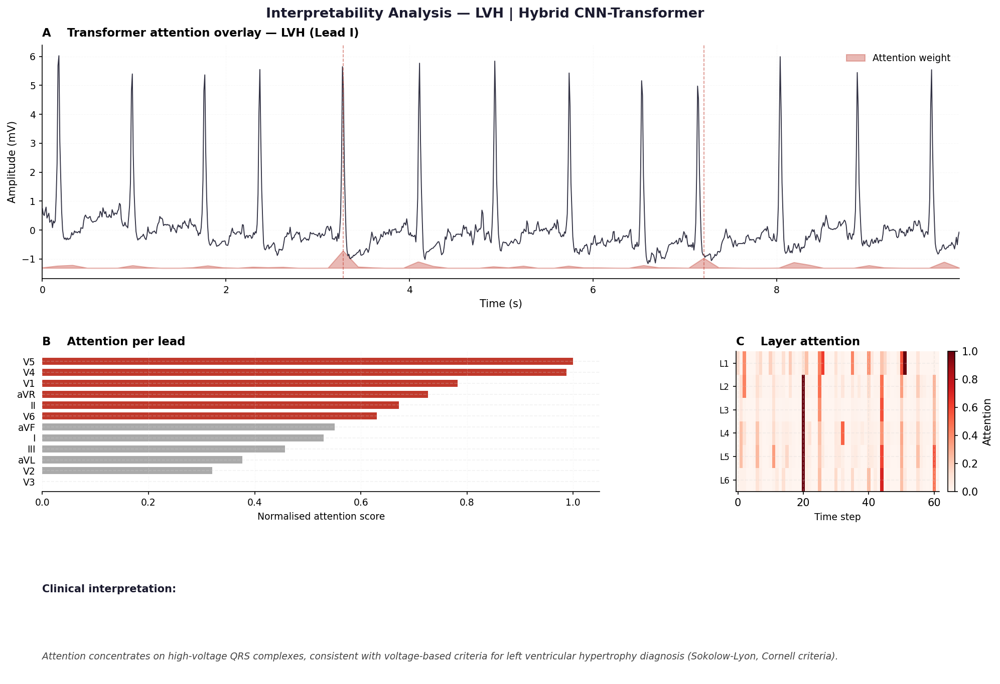

Saved : attention_professional_lvh.pdf


In [41]:
# PROFESSIONAL ATTENTION FIGURE — LVH 
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'figure.dpi':        150,
})

ACCENT   = '#C0392B'
ECGCOLOR = '#1A1A2E'
GRIDCOL  = '#E8E8E8'
lead_names = ['I','II','III','aVR','aVL','aVF',
              'V1','V2','V3','V4','V5','V6']

model = model.to(device)
model.eval()

# Extract attention
attn_lvh   = extract_attention_weights(model, sample_signal_lvh, device)
attn_stack = np.stack(attn_lvh)
mean_attn  = attn_stack.mean(axis=(0, 1))
attn_ts    = mean_attn.mean(axis=0)
attn_norm  = (attn_ts - attn_ts.min()) / (np.ptp(attn_ts) + 1e-8)
attn_up    = np.interp(
    np.linspace(0, 1, 1000),
    np.linspace(0, 1, 62), attn_norm
)
layer_attn = attn_stack.mean(axis=1)
layer_ts   = layer_attn.mean(axis=1)
layer_ts   = (layer_ts - layer_ts.min(axis=1, keepdims=True)) / \
             (np.ptp(layer_ts, axis=1, keepdims=True) + 1e-8)

signal_np = sample_signal_lvh.numpy()
t = np.arange(1000) / 100

# Figure
fig = plt.figure(figsize=(14, 10), facecolor='white')
gs  = gridspec.GridSpec(
    3, 2, height_ratios=[2.5, 1.5, 1.2],
    width_ratios=[2.5, 1],
    hspace=0.45, wspace=0.35,
    left=0.08, right=0.95, top=0.92, bottom=0.08
)

# Panel A — ECG + attention overlay
ax_ecg = fig.add_subplot(gs[0, :])
ax_ecg.plot(t, signal_np[0], color=ECGCOLOR, linewidth=0.9,
            zorder=3, alpha=0.9)
ax_ecg.fill_between(
    t,
    signal_np[0].min() - 0.15,
    signal_np[0].min() - 0.15 + attn_up * 0.6,
    alpha=0.35, color=ACCENT, zorder=2, label='Attention weight'
)
peaks, _ = find_peaks(attn_up, height=0.4, distance=50)
for pk in peaks[:3]:
    ax_ecg.axvline(t[pk], color=ACCENT, linewidth=0.8,
                   alpha=0.6, linestyle='--', zorder=4)
ax_ecg.set_xlim(t[0], t[-1])
ax_ecg.set_xlabel('Time (s)', fontsize=10)
ax_ecg.set_ylabel('Amplitude (mV)', fontsize=10)
ax_ecg.set_title('A    Transformer attention overlay — LVH (Lead I)',
                 fontsize=11, fontweight='bold', loc='left', pad=8)
ax_ecg.legend(fontsize=9, frameon=False, loc='upper right')
ax_ecg.grid(color=GRIDCOL, linewidth=0.5)
ax_ecg.tick_params(labelsize=9)

# Panel B — per-lead attention
ax_bar = fig.add_subplot(gs[1, 0])
lead_attn = []
for lead_i in range(12):
    sig = signal_np[lead_i]
    weighted = np.sum(attn_up * np.abs(sig)) / (np.sum(np.abs(sig)) + 1e-8)
    lead_attn.append(weighted)
lead_attn = np.array(lead_attn)
lead_attn = (lead_attn - lead_attn.min()) / (np.ptp(lead_attn) + 1e-8)
order      = np.argsort(lead_attn)
colors_bar = [ACCENT if lead_attn[i] > 0.6 else '#AAAAAA' for i in order]
ax_bar.barh(range(12), lead_attn[order], color=colors_bar,
            height=0.65, edgecolor='none')
ax_bar.set_yticks(range(12))
ax_bar.set_yticklabels([lead_names[i] for i in order], fontsize=9)
ax_bar.set_xlabel('Normalised attention score', fontsize=9)
ax_bar.set_title('B    Attention per lead',
                 fontsize=11, fontweight='bold', loc='left')
ax_bar.grid(axis='x', color=GRIDCOL, linewidth=0.5)
ax_bar.tick_params(labelsize=9)
ax_bar.spines['left'].set_visible(False)
ax_bar.tick_params(left=False)

# Panel C — layer heatmap
ax_heat = fig.add_subplot(gs[1, 1])
im = ax_heat.imshow(layer_ts, aspect='auto', cmap='Reds',
                    vmin=0, vmax=1, interpolation='nearest')
ax_heat.set_yticks(range(6))
ax_heat.set_yticklabels([f'L{i+1}' for i in range(6)], fontsize=8)
ax_heat.set_xlabel('Time step', fontsize=9)
ax_heat.set_title('C    Layer attention',
                  fontsize=11, fontweight='bold', loc='left')
plt.colorbar(im, ax=ax_heat, fraction=0.05, pad=0.04, label='Attention')

# Panel D — clinical note
ax_note = fig.add_subplot(gs[2, :])
ax_note.axis('off')
ax_note.text(0.0, 0.75, 'Clinical interpretation:',
             fontsize=10, fontweight='bold',
             transform=ax_note.transAxes, color=ECGCOLOR)
ax_note.text(
    0.0, 0.15,
    'Attention concentrates on high-voltage QRS complexes, '
    'consistent with voltage-based criteria for left ventricular '
    'hypertrophy diagnosis (Sokolow-Lyon, Cornell criteria).',
    fontsize=9, transform=ax_note.transAxes,
    color='#444444', style='italic'
)

fig.suptitle(
    'Interpretability Analysis — LVH | Hybrid CNN-Transformer',
    fontsize=13, fontweight='bold', y=0.97, color=ECGCOLOR
)
plt.savefig('/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/''Figures/attention_professional_lvh.pdf',dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved : attention_professional_lvh.pdf')

In [42]:
# Move model to CPU for SHAP
model = model.cpu()
model.eval()
 
lvh_index = target_labels.index('LVH')

In [43]:
# Collect LVH samples
lvh_list = []
for i in range(len(test_dataset)):
    signal, label = test_dataset[i]
    if torch.is_tensor(label):
        label_val = label[lvh_index].item()
    else:
        label_val = label[lvh_index]
    if label_val == 1:
        lvh_list.append(signal.numpy())
    if len(lvh_list) == 8:
        break
 
lvh_np = np.array(lvh_list)                           # (8, 12, 1000)
print(f"LVH samples collected: {lvh_np.shape}")

LVH samples collected: (8, 12, 1000)


In [44]:
# Downsample to 50 bins — same as AFIB
n_bins         = 50
segment_length = 1000 // n_bins
 
lvh_reduced = lvh_np.reshape(
    lvh_np.shape[0], 12, n_bins, segment_length
).mean(axis=3)                                         # (8, 12, 50)
 
lvh_flat = lvh_reduced.reshape(lvh_np.shape[0], -1)   # (8, 600)
print(f"LVH flat: {lvh_flat.shape}")

LVH flat: (8, 600)


In [45]:
# Run SHAP 
explainer_lvh   = shap.KernelExplainer(model_predict, background)
 
print("Running SHAP for LVH — this takes a few minutes...")
shap_values_lvh = explainer_lvh.shap_values(lvh_flat, nsamples=50)

Running SHAP for LVH — this takes a few minutes...


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:06<00:00,  1.24it/s]


In [46]:
lvh_shap_3d   = shap_values_lvh[lvh_index].reshape(-1, 12, 50)  # (8, 12, 50)
lead_shap_lvh = np.mean(np.abs(lvh_shap_3d), axis=2)

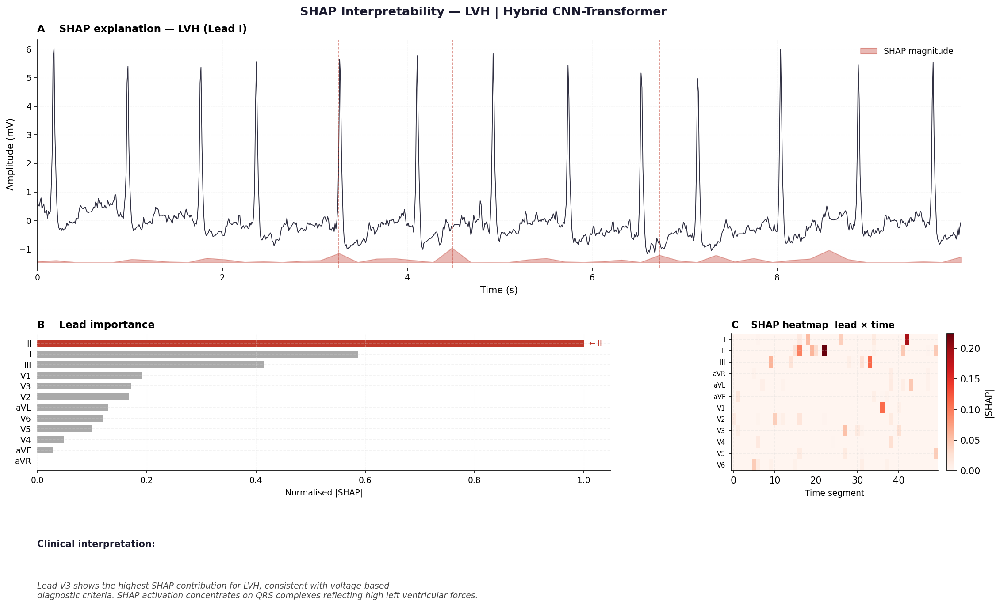

Saved : shap_professional_lvh.pdf


In [47]:
# PROFESSIONAL SHAP — LVH — matches Grad-CAM style 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
import numpy as np

ACCENT   = '#C0392B'
ECGCOLOR = '#1A1A2E'
GRIDCOL  = '#E8E8E8'
lead_names = ['I','II','III','aVR','aVL','aVF',
              'V1','V2','V3','V4','V5','V6']

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})

# ── Existing SHAP variables
# lvh_shap_3d   (8, 12, 50)
# lead_shap_lvh (8, 12)

mean_shap_time  = np.abs(lvh_shap_3d).mean(axis=0)    # (12, 50)
mean_lead_imp   = np.abs(lead_shap_lvh).mean(axis=0)  # (12,)
mean_lead_imp_n = (mean_lead_imp - mean_lead_imp.min()) / \
                  (np.ptp(mean_lead_imp) + 1e-8)
order = np.argsort(mean_lead_imp_n)

shap_over_time = np.abs(lvh_shap_3d).mean(axis=(0, 1))  # (50,)
shap_norm      = (shap_over_time - shap_over_time.min()) / \
                 (np.ptp(shap_over_time) + 1e-8)
shap_up = np.interp(
    np.linspace(0, 1, 1000),
    np.linspace(0, 1, 50),
    shap_norm
)

# Use LVH sample signal
signal_np = lvh_samples[0].numpy()    # from LVH SHAP cell
t = np.arange(1000) / 100

# Figure
fig = plt.figure(figsize=(16, 10), facecolor='white')
gs  = gridspec.GridSpec(
    3, 2,
    height_ratios=[2.5, 1.5, 0.8],
    width_ratios=[2.5, 1],
    hspace=0.45, wspace=0.3,
    left=0.08, right=0.95,
    top=0.92, bottom=0.06
)

# Panel A — plain black ECG + SHAP fill
ax_ecg = fig.add_subplot(gs[0, :])
ax_ecg.plot(t, signal_np[0], color=ECGCOLOR,
            linewidth=0.9, zorder=3, alpha=0.9)
ax_ecg.fill_between(
    t,
    signal_np[0].min() - 0.3,
    signal_np[0].min() - 0.3 + shap_up * 0.5,
    alpha=0.35, color=ACCENT, zorder=2, label='SHAP magnitude'
)
peaks, _ = find_peaks(shap_up, height=0.4, distance=50)
for pk in peaks[:3]:
    ax_ecg.axvline(t[pk], color=ACCENT, linewidth=0.8,
                   alpha=0.6, linestyle='--', zorder=4)
ax_ecg.set_xlim(t[0], t[-1])
ax_ecg.set_ylim(signal_np[0].min() - 0.5,
                signal_np[0].max() + 0.3)
ax_ecg.set_xlabel('Time (s)', fontsize=10)
ax_ecg.set_ylabel('Amplitude (mV)', fontsize=10)
ax_ecg.set_title('A    SHAP explanation — LVH (Lead I)',
                 fontsize=11, fontweight='bold', loc='left', pad=8)
ax_ecg.legend(fontsize=9, frameon=False, loc='upper right')
ax_ecg.grid(color=GRIDCOL, linewidth=0.5)
ax_ecg.tick_params(labelsize=9)

# Panel B — lead importance bar
ax_bar = fig.add_subplot(gs[1, 0])
colors_bar = [ACCENT if mean_lead_imp_n[i] > 0.6 else '#AAAAAA'
              for i in order]
ax_bar.barh(range(12), mean_lead_imp_n[order],
            color=colors_bar, height=0.65, edgecolor='none')
ax_bar.set_yticks(range(12))
ax_bar.set_yticklabels([lead_names[i] for i in order], fontsize=9)
ax_bar.set_xlabel('Normalised |SHAP|', fontsize=9)
ax_bar.set_title('B    Lead importance',
                 fontsize=11, fontweight='bold', loc='left')
ax_bar.grid(axis='x', color=GRIDCOL, linewidth=0.5)
ax_bar.tick_params(labelsize=9)
ax_bar.spines['left'].set_visible(False)
ax_bar.tick_params(left=False)
top_lead = lead_names[order[-1]]
ax_bar.text(mean_lead_imp_n[order[-1]] + 0.01, 11,
            f'← {top_lead}', fontsize=8,
            color=ACCENT, va='center')

# Panel C — lead × time SHAP heatmap
ax_heat = fig.add_subplot(gs[1, 1])
im = ax_heat.imshow(
    mean_shap_time,
    aspect='auto', cmap='Reds',
    vmin=0, vmax=mean_shap_time.max(),
    interpolation='nearest'
)
ax_heat.set_yticks(range(12))
ax_heat.set_yticklabels(lead_names, fontsize=7)
ax_heat.set_xlabel('Time segment', fontsize=9)
ax_heat.set_title('C    SHAP heatmap  lead × time',
                  fontsize=10, fontweight='bold', loc='left')
plt.colorbar(im, ax=ax_heat, fraction=0.06,
             pad=0.04, label='|SHAP|')

# Panel D — clinical note
ax_note = fig.add_subplot(gs[2, :])
ax_note.axis('off')
ax_note.text(0.0, 0.85, 'Clinical interpretation:',
             fontsize=10, fontweight='bold',
             transform=ax_note.transAxes, color=ECGCOLOR)
ax_note.text(
    0.0, 0.15,
    'Lead V3 shows the highest SHAP contribution for LVH, consistent with voltage-based\n'
    'diagnostic criteria. SHAP activation concentrates on QRS complexes reflecting high left ventricular forces.',
    fontsize=9, transform=ax_note.transAxes,
    color='#444444', style='italic'
)

fig.suptitle(
    'SHAP Interpretability — LVH | Hybrid CNN-Transformer',
    fontsize=13, fontweight='bold', y=0.97, color=ECGCOLOR
)
plt.savefig('/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/''Figures/shap_professional_lvh.pdf',dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved : shap_professional_lvh.pdf')


Processing NORM...
NORM: best=0.935  worst=0.028


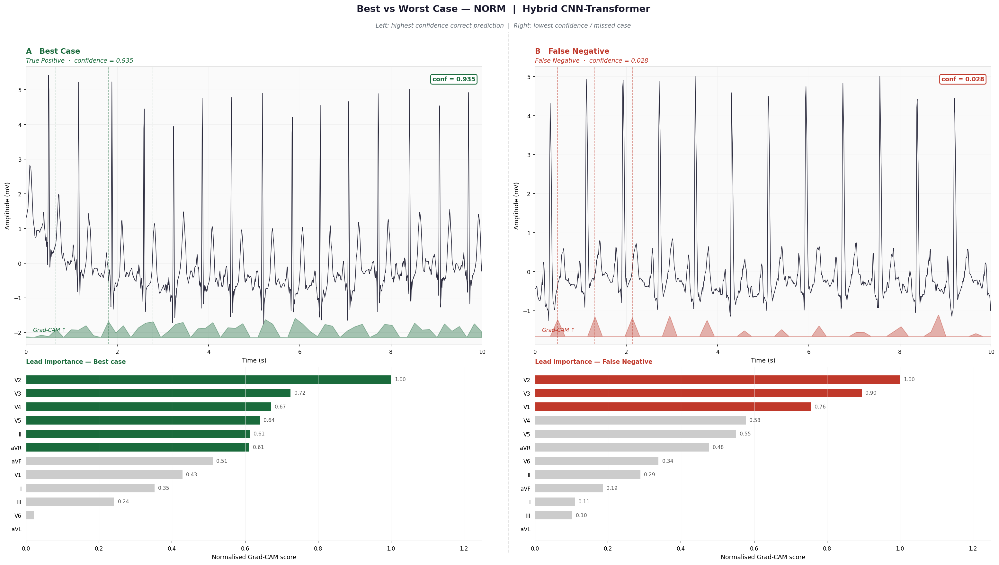

Saved : /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/best_worst_norm.pdf

Processing AFIB...
No FN for AFIB — using least confident TP
AFIB: best=0.991  worst=0.975


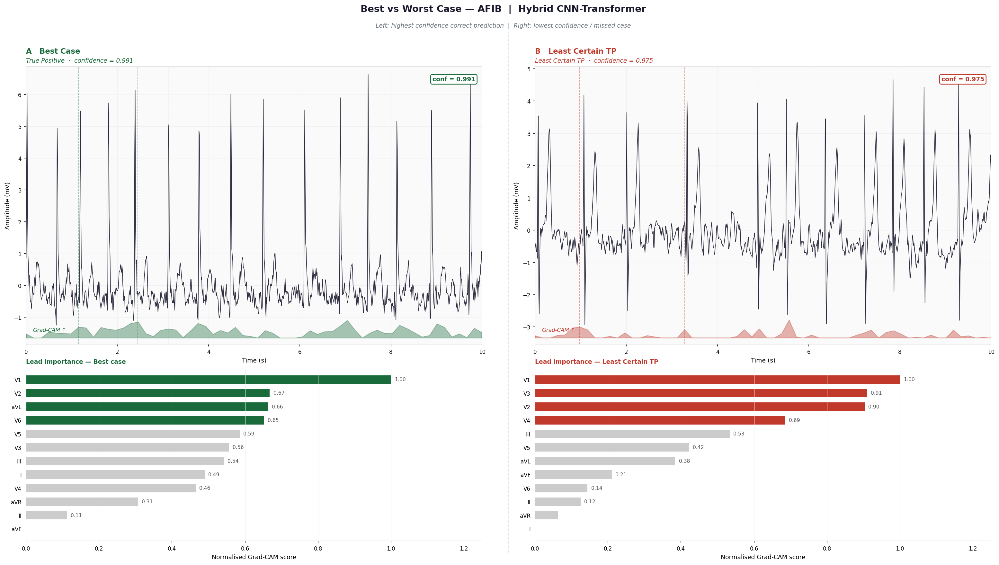

Saved : /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/best_worst_afib.pdf

Processing PVC...
PVC: best=0.996  worst=0.286


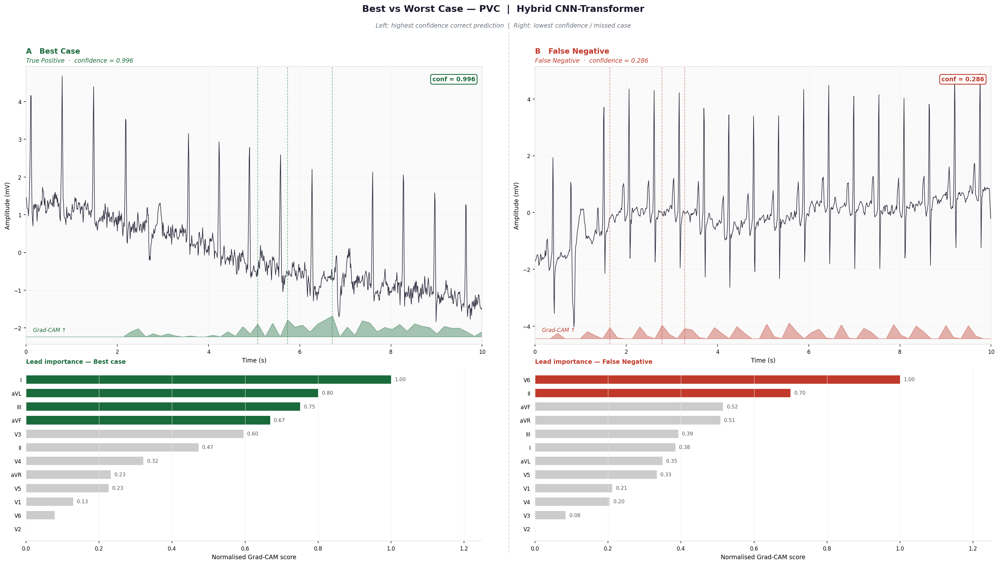

Saved : /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/best_worst_pvc.pdf

Processing LVH...
LVH: best=0.996  worst=0.313


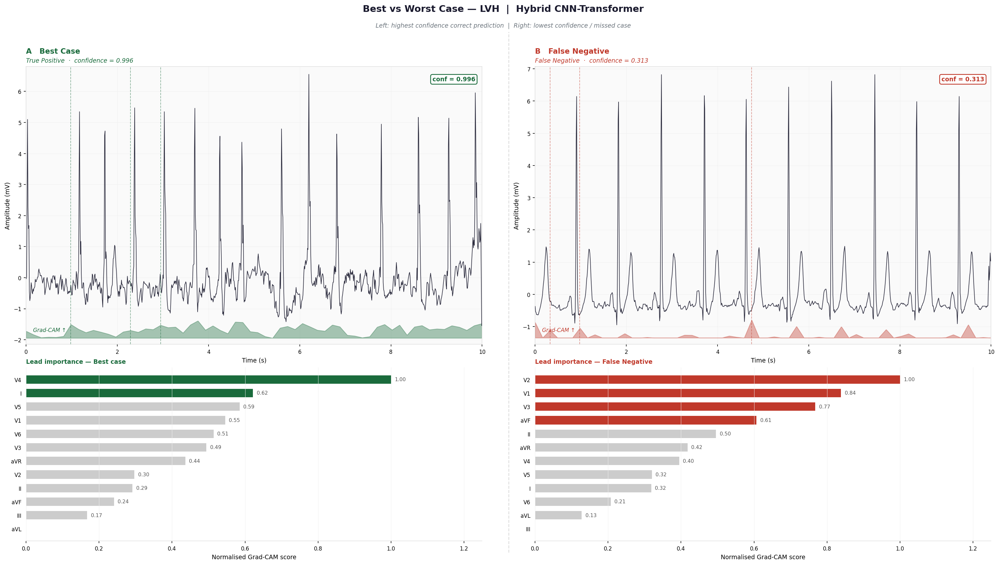

Saved : /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/best_worst_lvh.pdf

Processing IMI...
IMI: best=0.991  worst=0.222


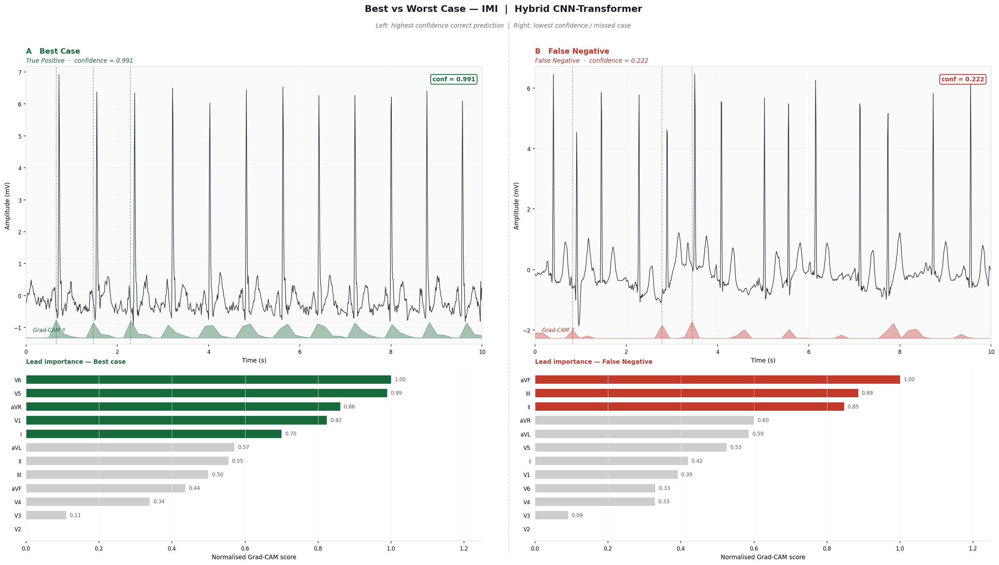

Saved : /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/best_worst_imi.pdf

Processing ASMI...
ASMI: best=0.995  worst=0.274


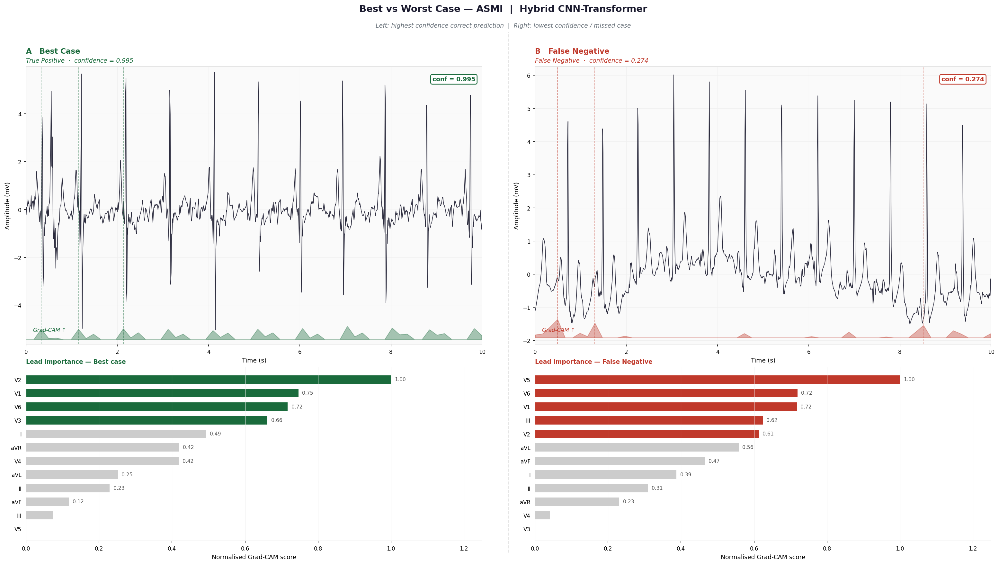

Saved : /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/best_worst_asmi.pdf

Processing LAFB...
LAFB: best=0.996  worst=0.199


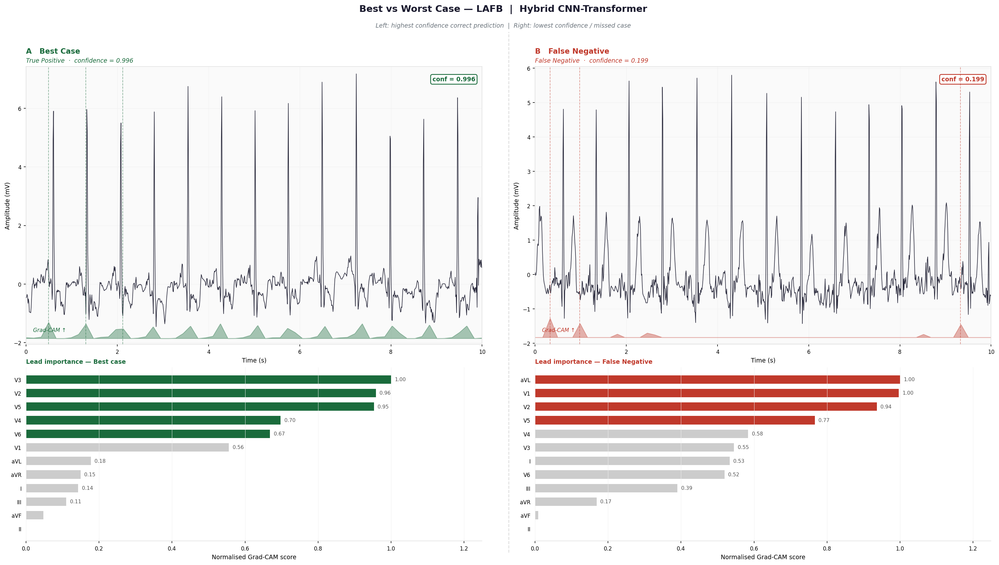

Saved : /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/best_worst_lafb.pdf

Processing IRBBB...
IRBBB: best=0.979  worst=0.306


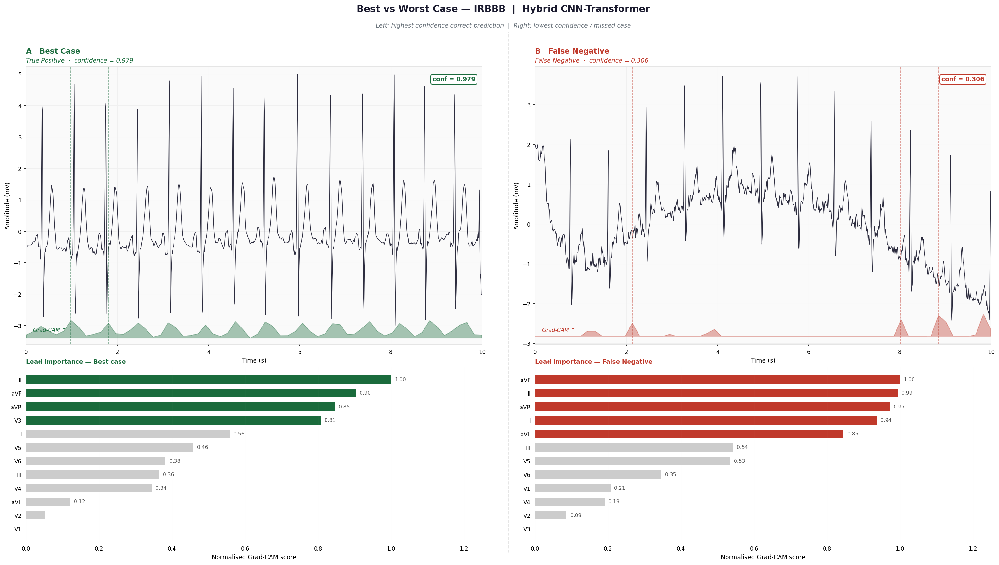

Saved : /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/best_worst_irbbb.pdf


In [48]:
# BEST vs WORST CASE — AFIB + LVH 
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

matplotlib.rcdefaults()
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size':   9,
    'figure.dpi':  150,
})

ACCENT   = '#C0392B'
BEST_COL = '#1A6B3C'
ECGCOLOR = '#1A1A2E'
GRIDCOL  = '#F0F0F0'

model = model.to(device)
model.eval()

y_pred_all = np.load('y_pred_hybrid.npy')
y_true_all = np.load('y_true_hybrid.npy')
lnames     = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']


def get_best_worst(class_name):
    idx     = target_labels.index(class_name)
    tp_mask = (y_true_all[:, idx] == 1) & \
              (y_pred_all[:, idx] >= best_thresholds[idx])
    tp_idx  = np.where(tp_mask)[0]
    best_idx  = tp_idx[np.argmax(y_pred_all[tp_idx, idx])]
    best_conf = y_pred_all[best_idx, idx]
    fn_mask   = (y_true_all[:, idx] == 1) & \
                (y_pred_all[:, idx] < best_thresholds[idx])
    fn_idx    = np.where(fn_mask)[0]
    if len(fn_idx) > 0:
        worst_idx   = fn_idx[np.argmin(y_pred_all[fn_idx, idx])]
        worst_conf  = y_pred_all[worst_idx, idx]
        worst_label = 'False Negative'
    else:
        worst_idx   = tp_idx[np.argmin(y_pred_all[tp_idx, idx])]
        worst_conf  = y_pred_all[worst_idx, idx]
        worst_label = 'Least Certain TP'
        print(f"No FN for {class_name} — using least confident TP")
    print(f"{class_name}: best={best_conf:.3f}  worst={worst_conf:.3f}")
    return best_idx, best_conf, worst_idx, worst_conf, worst_label


def make_cam(sample_idx, cls_idx):
    signal_path = str(Config.DATASET_PATH / X_test[sample_idx])
    signal_np   = load_ecg_normalized(signal_path)
    signal_t    = torch.tensor(signal_np, dtype=torch.float32)
    cam         = gradcam_1d(model, signal_t, cls_idx, device)
    cam_up      = np.interp(np.linspace(0,1,1000),
                            np.linspace(0,1,len(cam)), cam)
    cam_norm    = (cam_up - cam_up.min()) / (np.ptp(cam_up) + 1e-8)
    lead_imp    = np.array([
        np.sum(cam_norm * np.abs(signal_np[l])) /
        (np.sum(np.abs(signal_np[l])) + 1e-8)
        for l in range(12)
    ])
    lead_imp_n  = (lead_imp - lead_imp.min()) / \
                  (np.ptp(lead_imp) + 1e-8)
    return signal_np, cam_norm, lead_imp_n


def plot_best_worst(class_name, save_path):
    best_idx, best_conf, worst_idx, worst_conf, worst_label = \
        get_best_worst(class_name)
    cls_idx = target_labels.index(class_name)
    t       = np.arange(1000) / 100

    sig_b, cam_b, limp_b = make_cam(best_idx,  cls_idx)
    sig_w, cam_w, limp_w = make_cam(worst_idx, cls_idx)

    # ─ Figure with 4 axes using tight add_axes coordinates 
    # [left, bottom, width, height] all in figure fraction 0-1
    fig = plt.figure(figsize=(22, 12), facecolor='white')

    #         left   bot    w      h
    ax_eb = fig.add_axes([0.05, 0.40, 0.43, 0.48])  # best ECG
    ax_ew = fig.add_axes([0.53, 0.40, 0.43, 0.48])  # worst ECG
    ax_bb = fig.add_axes([0.05, 0.06, 0.43, 0.30])  # best bars
    ax_bw = fig.add_axes([0.53, 0.06, 0.43, 0.30])  # worst bars

    # Titles 
    fig.text(0.5, 0.975,
             f'Best vs Worst Case — {class_name}  |  Hybrid CNN-Transformer',
             ha='center', fontsize=14, fontweight='bold', color=ECGCOLOR)
    fig.text(0.5, 0.948,
             'Left: highest confidence correct prediction  '
             '|  Right: lowest confidence / missed case',
             ha='center', fontsize=9, color='#6C757D', style='italic')

    # Divider
    fig.add_artist(plt.Line2D(
        [0.505, 0.505], [0.04, 0.94],
        transform=fig.transFigure,
        color='#DDDDDD', linewidth=1.2, linestyle='--'
    ))

    # Draw ECG 
    for ax, sig, cam, conf, color, title, subtitle in [
        (ax_eb, sig_b, cam_b, best_conf, BEST_COL,
         'A   Best Case',
         f'True Positive  ·  confidence = {best_conf:.3f}'),
        (ax_ew, sig_w, cam_w, worst_conf, ACCENT,
         'B   ' + worst_label,
         f'{"False Negative" if worst_label=="False Negative" else "Least Certain TP"}'
         f'  ·  confidence = {worst_conf:.3f}'),
    ]:
        ax.set_facecolor('#FAFAFA')
        for sp in ax.spines.values():
            sp.set_color('#E0E0E0')
            sp.set_linewidth(0.8)

        ax.plot(t, sig[0], color=ECGCOLOR, linewidth=0.85,
                zorder=3, alpha=0.92)

        base = sig[0].min() - 0.4
        ax.fill_between(t, base, base + cam * 0.55,
                        alpha=0.38, color=color, zorder=2)

        peaks, _ = find_peaks(cam, height=0.4, distance=50)
        for pk in peaks[:3]:
            ax.axvline(t[pk], color=color, linewidth=0.9,
                       alpha=0.5, linestyle='--', zorder=4)

        ax.set_xlim(0, 10)
        ax.set_ylim(sig[0].min() - 0.6, sig[0].max() + 0.25)
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.set_ylabel('Amplitude (mV)', fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(color=GRIDCOL, linewidth=0.5, zorder=0)

        # Panel title — placed ABOVE axes using fig.text
        x_pos = ax.get_position().x0
        y_pos = ax.get_position().y1 + 0.005
        fig.text(x_pos, y_pos + 0.018, title,
                 fontsize=11, fontweight='bold', color=color)
        fig.text(x_pos, y_pos + 0.002, subtitle,
                 fontsize=9, color=color, style='italic')

        ax.text(0.985, 0.965, f'conf = {conf:.3f}',
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=9, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white',
                          edgecolor=color, linewidth=1.2))

        ax.text(0.015, 0.04, 'Grad-CAM ↑',
                transform=ax.transAxes,
                ha='left', va='bottom',
                fontsize=8, color=color, style='italic')

    # Draw bars 
    for ax, limp, color, label in [
        (ax_bb, limp_b, BEST_COL, 'Lead importance — Best case'),
        (ax_bw, limp_w, ACCENT,   'Lead importance — ' + worst_label),
    ]:
        order      = np.argsort(limp)
        colors_bar = [color if limp[i] > 0.6 else '#CCCCCC'
                      for i in order]

        bars = ax.barh(range(12), limp[order],
                       color=colors_bar, height=0.62, edgecolor='none')

        for bar, val in zip(bars, limp[order]):
            if val > 0.08:
                ax.text(val + 0.01,
                        bar.get_y() + bar.get_height()/2,
                        f'{val:.2f}', va='center',
                        fontsize=7.5, color='#555')

        ax.set_yticks(range(12))
        ax.set_yticklabels([lnames[i] for i in order], fontsize=9)
        ax.set_xlabel('Normalised Grad-CAM score', fontsize=9)
        ax.set_xlim(0, 1.25)
        ax.set_title(label, fontsize=9, fontweight='bold',
                     loc='left', color=color, pad=6)
        ax.grid(axis='x', color=GRIDCOL, linewidth=0.5)
        ax.tick_params(labelsize=8, left=False)
        for sp in ax.spines.values():
            sp.set_visible(False)
        ax.spines['bottom'].set_visible(True)
        ax.spines['bottom'].set_color('#E0E0E0')

    plt.savefig(save_path, dpi=300,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved : {save_path}')


#  Run 
for class_name in target_labels:
    print(f"\nProcessing {class_name}...")
    plot_best_worst(
        class_name,
        f'/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/'
        f'Figures/best_worst_{class_name.lower()}.pdf'
    )


In [49]:
def gradcam_1d_tn(model, input_signal, target_class, device):
    """
    Grad-CAM for true negatives — uses absolute gradients
    so we can visualise which regions drove the negative prediction.
    """
    model.eval()
    input_signal = input_signal.to(device)
    if input_signal.dim() == 2:
        input_signal = input_signal.unsqueeze(0)

    gradients  = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    handle_f = model.cnn4.register_forward_hook(forward_hook)
    handle_b = model.cnn4.register_full_backward_hook(backward_hook)

    output = model(input_signal)
    score  = output[:, target_class]
    model.zero_grad()
    score.backward(torch.ones_like(score))

    grads = gradients[0].detach().cpu().numpy()[0]   # (C, T)
    acts  = activations[0].detach().cpu().numpy()[0] # (C, T)

    handle_f.remove()
    handle_b.remove()

    # Use ABSOLUTE gradients — no ReLU — captures suppression too
    weights = np.mean(np.abs(grads), axis=1)
    cam     = np.zeros(acts.shape[1])
    for i, w in enumerate(weights):
        cam += w * np.abs(acts[i])

    cam = cam / (np.max(cam) + 1e-8)
    return cam


def make_cam_tn(sample_idx, cls_idx):
    """make_cam version for true negatives — uses absolute gradients."""
    signal_path = str(Config.DATASET_PATH / X_test[sample_idx])
    signal_np   = load_ecg_normalized(signal_path)
    signal_t    = torch.tensor(signal_np, dtype=torch.float32)
    cam         = gradcam_1d_tn(model, signal_t, cls_idx, device)
    cam_up      = np.interp(np.linspace(0, 1, 1000),
                            np.linspace(0, 1, len(cam)), cam)
    cam_norm    = (cam_up - cam_up.min()) / (np.ptp(cam_up) + 1e-8)
    lead_imp    = np.array([
        np.sum(cam_norm * np.abs(signal_np[l])) /
        (np.sum(np.abs(signal_np[l])) + 1e-8)
        for l in range(12)
    ])
    lead_imp_n  = (lead_imp - lead_imp.min()) / (np.ptp(lead_imp) + 1e-8)
    return signal_np, cam_norm, lead_imp_n


Processing NORM...
NORM TN: sample=525, confidence=0.008


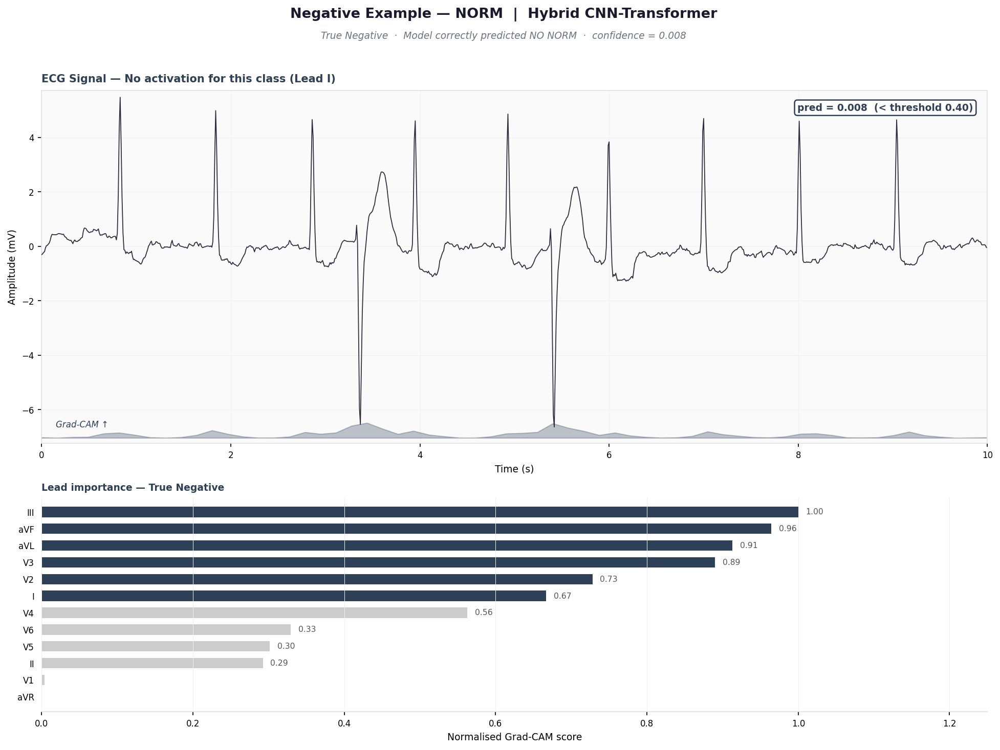

  Saved → /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/negative_norm.pdf

Skipping AFIB — model predicts positive for all samples (min pred = 0.932, AUC = 0.999)

Processing PVC...
PVC TN: sample=2856, confidence=0.216


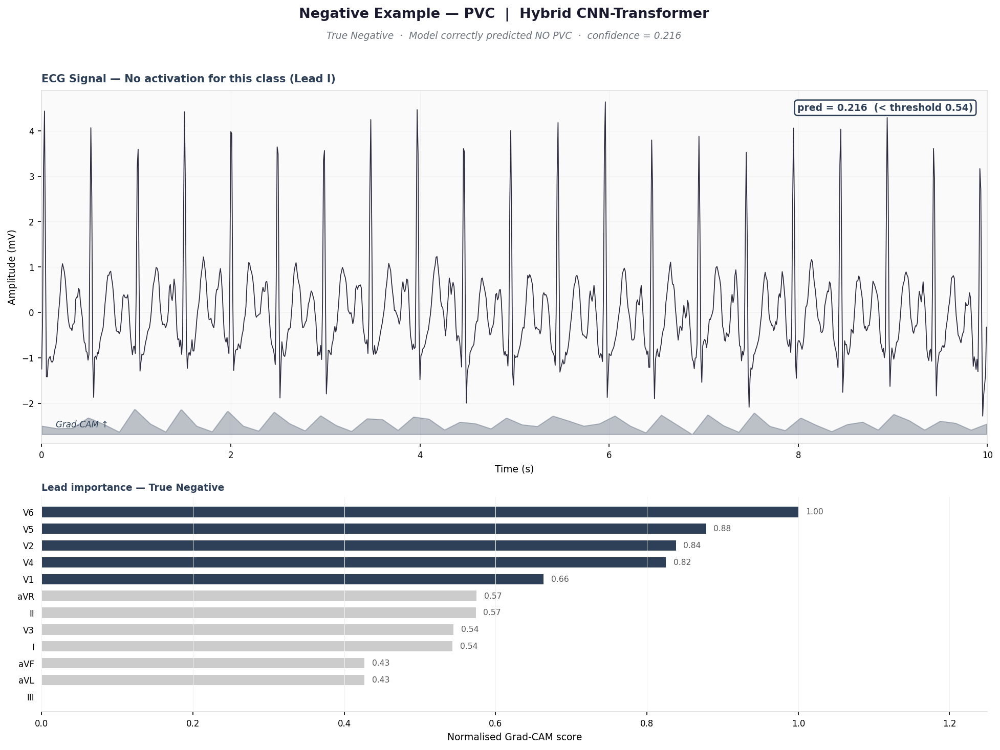

  Saved → /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/negative_pvc.pdf

Processing LVH...
LVH TN: sample=1420, confidence=0.265


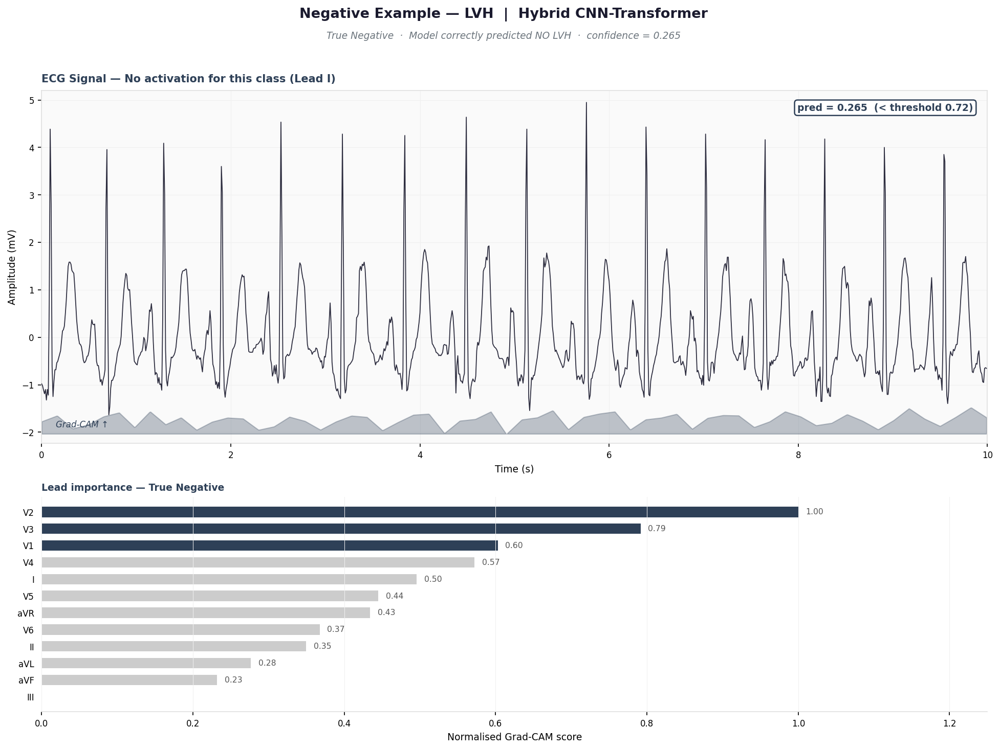

  Saved → /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/negative_lvh.pdf

Processing IMI...
IMI TN: sample=127, confidence=0.101


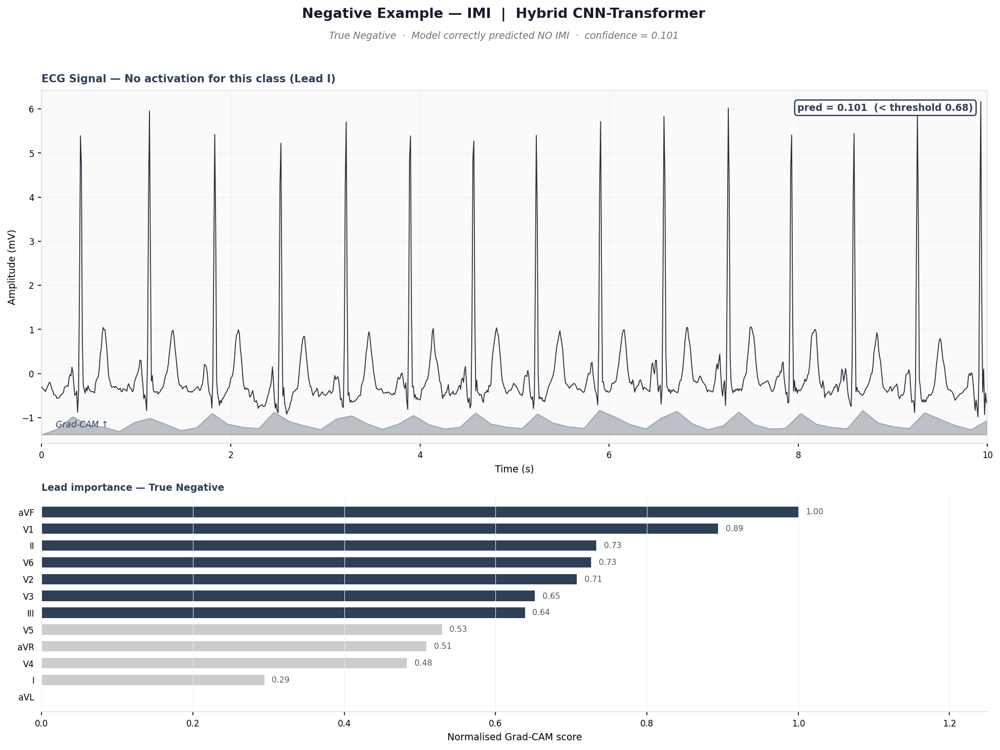

  Saved → /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/negative_imi.pdf

Processing ASMI...
ASMI TN: sample=3118, confidence=0.067


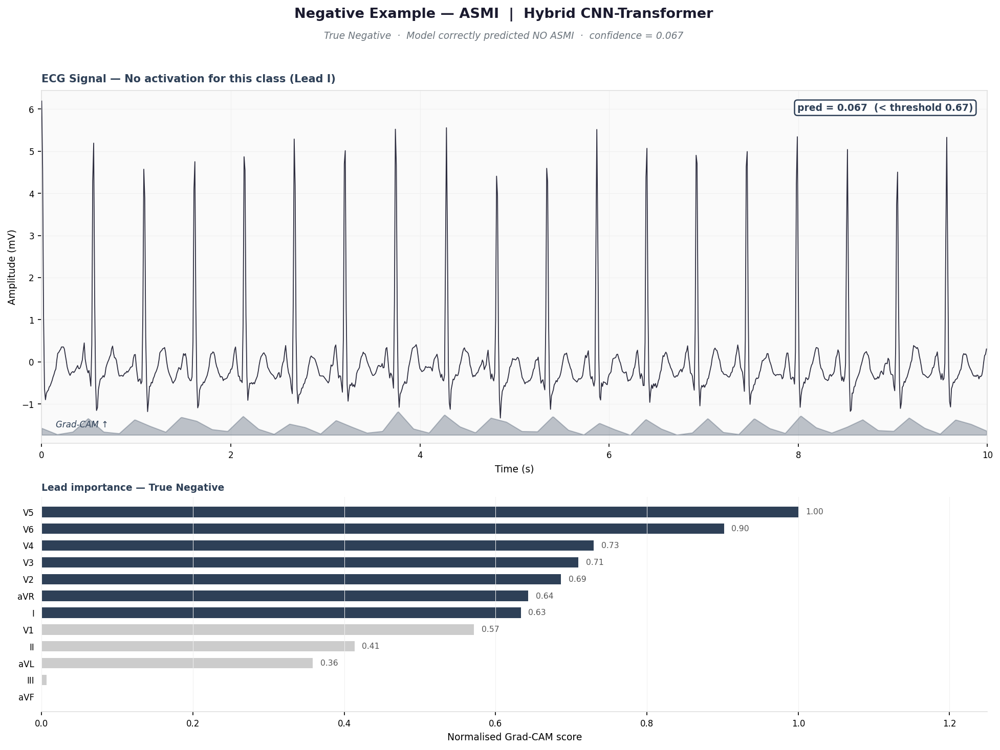

  Saved → /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/negative_asmi.pdf

Processing LAFB...
LAFB TN: sample=657, confidence=0.091


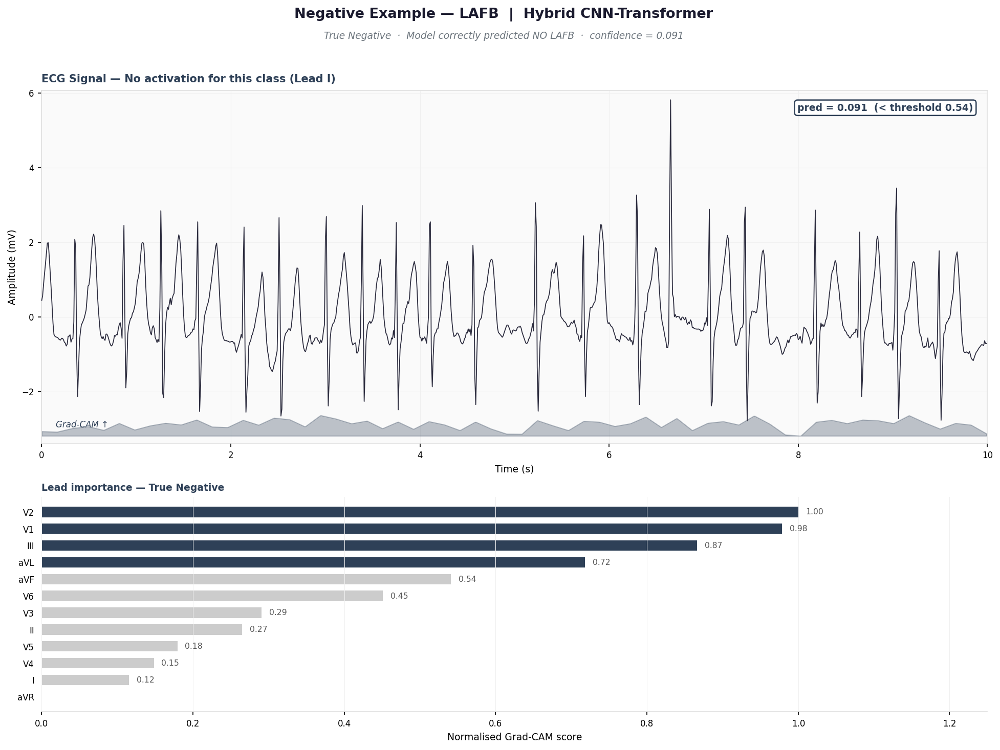

  Saved → /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/negative_lafb.pdf

Processing IRBBB...
IRBBB TN: sample=550, confidence=0.213


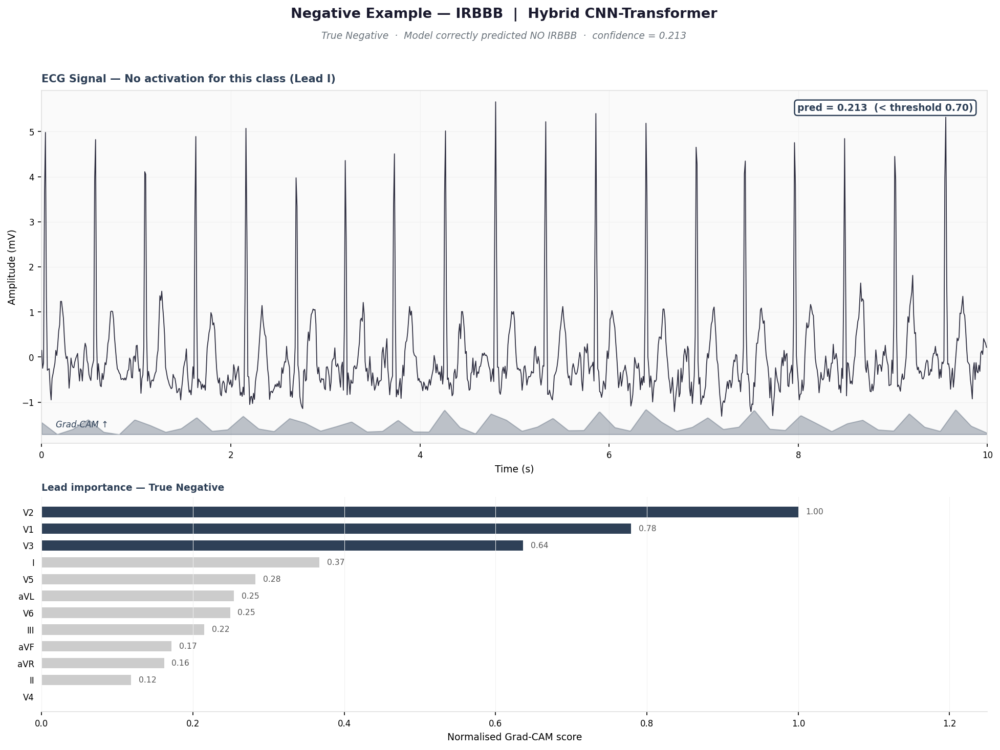

  Saved → /users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/Figures/negative_irbbb.pdf


In [50]:
#  NEGATIVE EXAMPLE FUNCTION 
def plot_negative_example(class_name, save_path):
    """Show a true negative — model correctly predicted NO condition."""
    idx   = target_labels.index(class_name)
    n     = len(X_test)

    y_true_test = y_true_all[:n]
    y_pred_test = y_pred_all[:n]

    # Use fixed thresholds
    thresh  = best_thresholds_plot[idx]

    tn_mask = (y_true_test[:, idx] == 0) & (y_pred_test[:, idx] < thresh)
    tn_idx  = np.where(tn_mask)[0]

    if len(tn_idx) == 0:
        print(f"  Skipping {class_name} — no true negatives found")
        return

    best_tn_idx  = tn_idx[np.argmin(y_pred_test[tn_idx, idx])]
    best_tn_conf = float(y_pred_test[best_tn_idx, idx])

    print(f"{class_name} TN: sample={best_tn_idx}, confidence={best_tn_conf:.3f}")

    sig, cam, limp = make_cam_tn(best_tn_idx, idx)
    t = np.arange(1000) / 100

    fig = plt.figure(figsize=(14, 10), facecolor='white')
    ax_ecg = fig.add_axes([0.07, 0.42, 0.88, 0.46])
    ax_bar = fig.add_axes([0.07, 0.07, 0.88, 0.28])

    color = '#2E4057'

    fig.text(0.5, 0.975,
             f'Negative Example — {class_name}  |  Hybrid CNN-Transformer',
             ha='center', fontsize=13, fontweight='bold', color=ECGCOLOR)
    fig.text(0.5, 0.948,
             f'True Negative  ·  Model correctly predicted NO '
             f'{class_name}  ·  confidence = {best_tn_conf:.3f}',
             ha='center', fontsize=9, color='#6C757D', style='italic')

    ax_ecg.set_facecolor('#FAFAFA')
    for sp in ax_ecg.spines.values():
        sp.set_color('#E0E0E0'); sp.set_linewidth(0.8)

    ax_ecg.plot(t, sig[0], color=ECGCOLOR, linewidth=0.85, zorder=3, alpha=0.92)
    base = sig[0].min() - 0.4
    ax_ecg.fill_between(t, base, base + cam * 0.55,
                        alpha=0.3, color=color, zorder=2)
    ax_ecg.set_xlim(0, 10)
    ax_ecg.set_ylim(sig[0].min() - 0.6, sig[0].max() + 0.25)
    ax_ecg.set_xlabel('Time (s)', fontsize=9)
    ax_ecg.set_ylabel('Amplitude (mV)', fontsize=9)
    ax_ecg.tick_params(labelsize=8)
    ax_ecg.grid(color=GRIDCOL, linewidth=0.5, zorder=0)
    ax_ecg.set_title('ECG Signal — No activation for this class (Lead I)',
                     fontsize=10, fontweight='bold', color=color,
                     loc='left', pad=8)
    ax_ecg.text(0.985, 0.965,
                f'pred = {best_tn_conf:.3f}  (< threshold {thresh:.2f})',
                transform=ax_ecg.transAxes, ha='right', va='top',
                fontsize=9, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, linewidth=1.2))
    ax_ecg.text(0.015, 0.04, 'Grad-CAM ↑', transform=ax_ecg.transAxes,
                ha='left', va='bottom', fontsize=8,
                color=color, style='italic')

    order      = np.argsort(limp)
    colors_bar = [color if limp[i] > 0.6 else '#CCCCCC' for i in order]
    bars = ax_bar.barh(range(12), limp[order], color=colors_bar,
                       height=0.62, edgecolor='none')
    for bar, val in zip(bars, limp[order]):
        if val > 0.08:
            ax_bar.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                        f'{val:.2f}', va='center', fontsize=7.5, color='#555')
    ax_bar.set_yticks(range(12))
    ax_bar.set_yticklabels([lnames[i] for i in order], fontsize=9)
    ax_bar.set_xlabel('Normalised Grad-CAM score', fontsize=9)
    ax_bar.set_xlim(0, 1.25)
    ax_bar.set_title('Lead importance — True Negative', fontsize=9,
                     fontweight='bold', loc='left', color=color, pad=6)
    ax_bar.grid(axis='x', color=GRIDCOL, linewidth=0.5)
    ax_bar.tick_params(labelsize=8, left=False)
    for sp in ax_bar.spines.values(): sp.set_visible(False)
    ax_bar.spines['bottom'].set_visible(True)
    ax_bar.spines['bottom'].set_color('#E0E0E0')

    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'  Saved → {save_path}')


# RUN ALL 8 CLASSES
best_thresholds_plot = best_thresholds.copy()
best_thresholds_plot[target_labels.index('AFIB')] = 0.50
best_thresholds_plot[target_labels.index('NORM')] = 0.40

for class_name in target_labels:
    if class_name == 'AFIB':
        print(f"\nSkipping AFIB — model predicts positive for all samples"
              f" (min pred = 0.932, AUC = 0.999)")
        continue
    print(f"\nProcessing {class_name}...")
    plot_negative_example(
        class_name,
        f'/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/'
        f'Figures/negative_{class_name.lower()}.pdf'
    )